# Advanced Time Series Forecasting, Optimization and Explainability

**Course:** Advanced Topics in Deep Learning — 2nd Semester 2025/2026

**Dataset:** Jena Climate (Weather) — Air Temperature Forecasting

**Task:** Multivariate-input, univariate-output, multi-step forecasting

---

**Group Members:**
- David Isaac — 120064
- David Volovei — 1200...
- Eduardo Martins — 120063

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Data Loading](#2-data-loading)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Data Preprocessing](#4-data-preprocessing)
5. [Windowing & DataLoaders](#5-windowing--dataloaders)
6. [Baseline Models](#6-baseline-models)
7. [Evolutionary Optimization](#7-evolutionary-optimization)
8. [Synthetic Data Generation (Optional/Bonus)](#8-synthetic-data-generation-optionalbonus)
9. [Explainable AI (XAI)](#9-explainable-ai-xai)
10. [Efficiency & Resource Analysis](#10-efficiency--resource-analysis)
11. [Comparative Analysis & Discussion](#11-comparative-analysis--discussion)
12. [Conclusion](#12-conclusion)

---
## 1. Setup & Imports

Install and import all required libraries. Set random seeds for reproducibility.

In [1]:
# !pip install -r "requirements.txt"

In [ ]:
#  Core Libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')
import random

#  Deep Learning 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#  Scikit-learn 
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import shap
from lime import lime_tabular


from deap import base, creator, tools, algorithms  # Option A: DEAP
# import optuna  # Option B: Optuna with evolutionary sampler


import urllib.request
import zipfile


Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
#  Reproducibility 
SEED = 33 # 33 RULES THE WORLD 

def set_seed(seed=SEED):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

#  Device Configuration 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #if you have a GPU, use it. Otherwise, use the CPU.
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

---
## 2. Data Loading

Load the Jena Climate dataset. Keep only the **required variables**:
- `Date Time` — timestamp
- `T (degC)` — air temperature (**TARGET**)
- `p (mbar)` — atmospheric pressure
- `rh (%)` — relative humidity
- `wv (m/s)` — wind speed
- `max. wv (m/s)` — maximum wind speed
- `wd (deg)` — wind direction

In [ ]:
DATA_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
DATA_DIR = "data/"
DATA_FILE = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")

#if the code doenst work for click on the url and download the file manually, then place it in the data directory. 
# The code will check if the file exists before attempting to download it, so you won't have to worry about it trying to download again if you already have it.
if not os.path.exists(DATA_FILE):
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv.zip")
    print("Downloading Jena Climate dataset")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)
    print("Done")
else:
    print("Dataset already exists, skipping download.")

df_raw = pd.read_csv(DATA_FILE)
print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()


Dataset already exists, skipping download.
Raw dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
# the columns we need for our analysis and modeling. We will focus on the following columns:
REQUIRED_COLS = ['Date Time', 'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
TARGET_COL = 'T (degC)' # We will be predicting the temperature, so this is our target variable.
df = df_raw[REQUIRED_COLS].copy()

df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time')
df = df.sort_index()


print(df.isnull().sum())
print(f"Duplicate timestamps: {df.index.duplicated().sum()}")
df.describe()

T (degC)         0
p (mbar)         0
rh (%)           0
wv (m/s)         0
max. wv (m/s)    0
wd (deg)         0
dtype: int64
Duplicate timestamps: 327


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,9.450147,989.212776,76.008259,1.702224,3.056555,174.743738
std,8.423365,8.358481,16.476175,65.446714,69.016932,86.681693
min,-23.010000,913.600000,12.950000,-9999.000000,-9999.000000,0.000000
25%,3.360000,984.200000,65.210000,0.990000,1.760000,124.900000
50%,9.420000,989.580000,79.300000,1.760000,2.960000,198.100000
75%,15.470000,994.720000,89.400000,2.860000,4.740000,234.100000
max,37.280000,1015.350000,100.000000,28.490000,23.500000,360.000000


---
## 3. Exploratory Data Analysis

Understand the structure and patterns in the data before modelling.
Here are some key EDA steps we will perform:
- **Full time series plot**: Visualize the entire temperature time series to identify overall trends and seasonality.
- **Zoomed-in view**: Focus on a specific month to see finer details and short-term patterns.
- **Seasonal decomposition**: Decompose the time series into trend, seasonal, and residual components to understand underlying patterns.
- **Correlation analysis**: Analyze correlations between the target variable and other features to identify potential predictors.

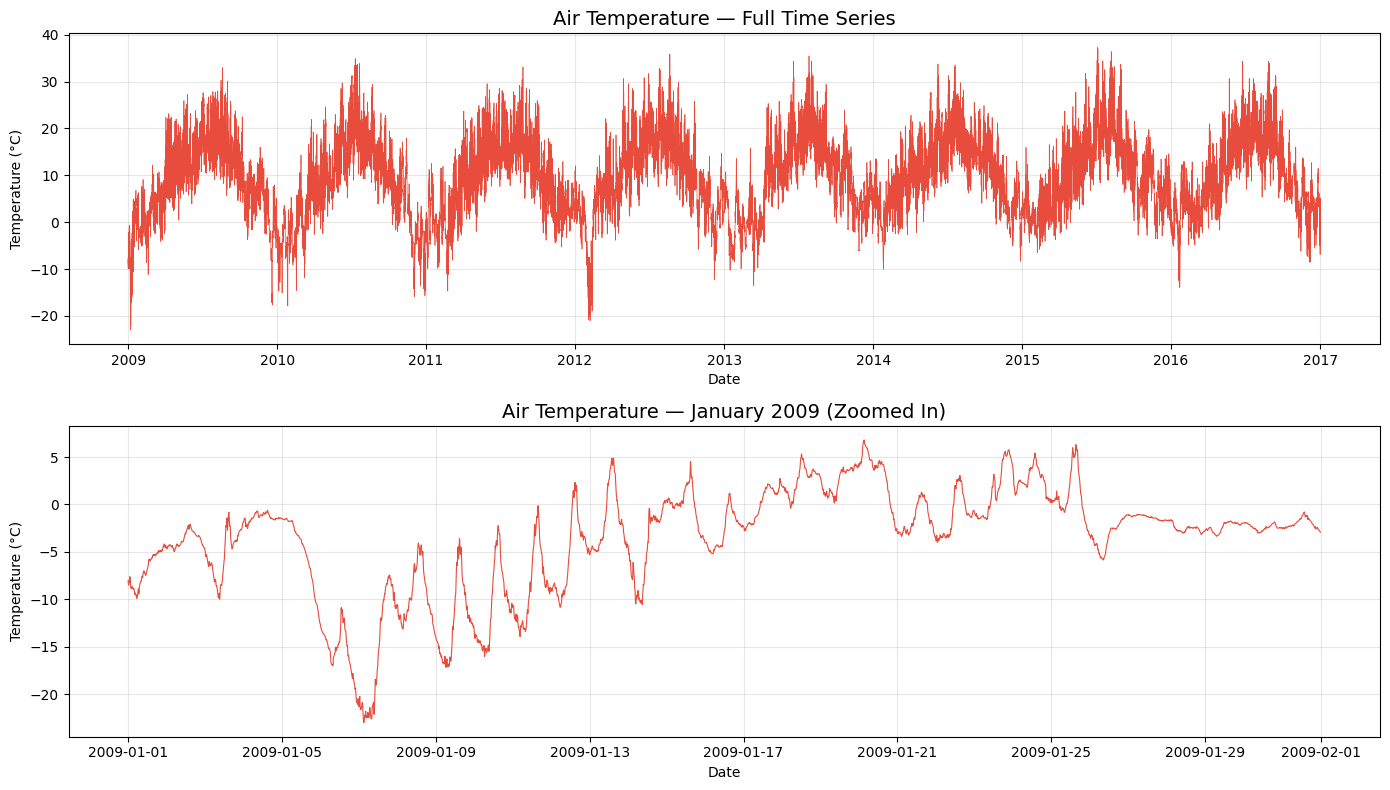

In [ ]:
#  Full time series plot 
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df['T (degC)'], linewidth=0.5, color='#e74c3c')
axes[0].set_title('Air Temperature — Full Time Series', fontsize=14)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_xlabel('Date')
axes[0].grid(True, alpha=0.3)

#  Zoomed-in view: first month 
one_month = df.loc['2009-01-01':'2009-01-31']
axes[1].plot(one_month.index, one_month['T (degC)'], linewidth=0.8, color='#e74c3c')
axes[1].set_title('Air Temperature — January 2009 (Zoomed In)', fontsize=14)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comments:
# - Clear yearly seasonality (warm summers, cold winters)
# - Daily patterns visible in the zoomed view (warmer during the day, cooler at night)
# - Some noise/short-term fluctuations present, typical of weather data


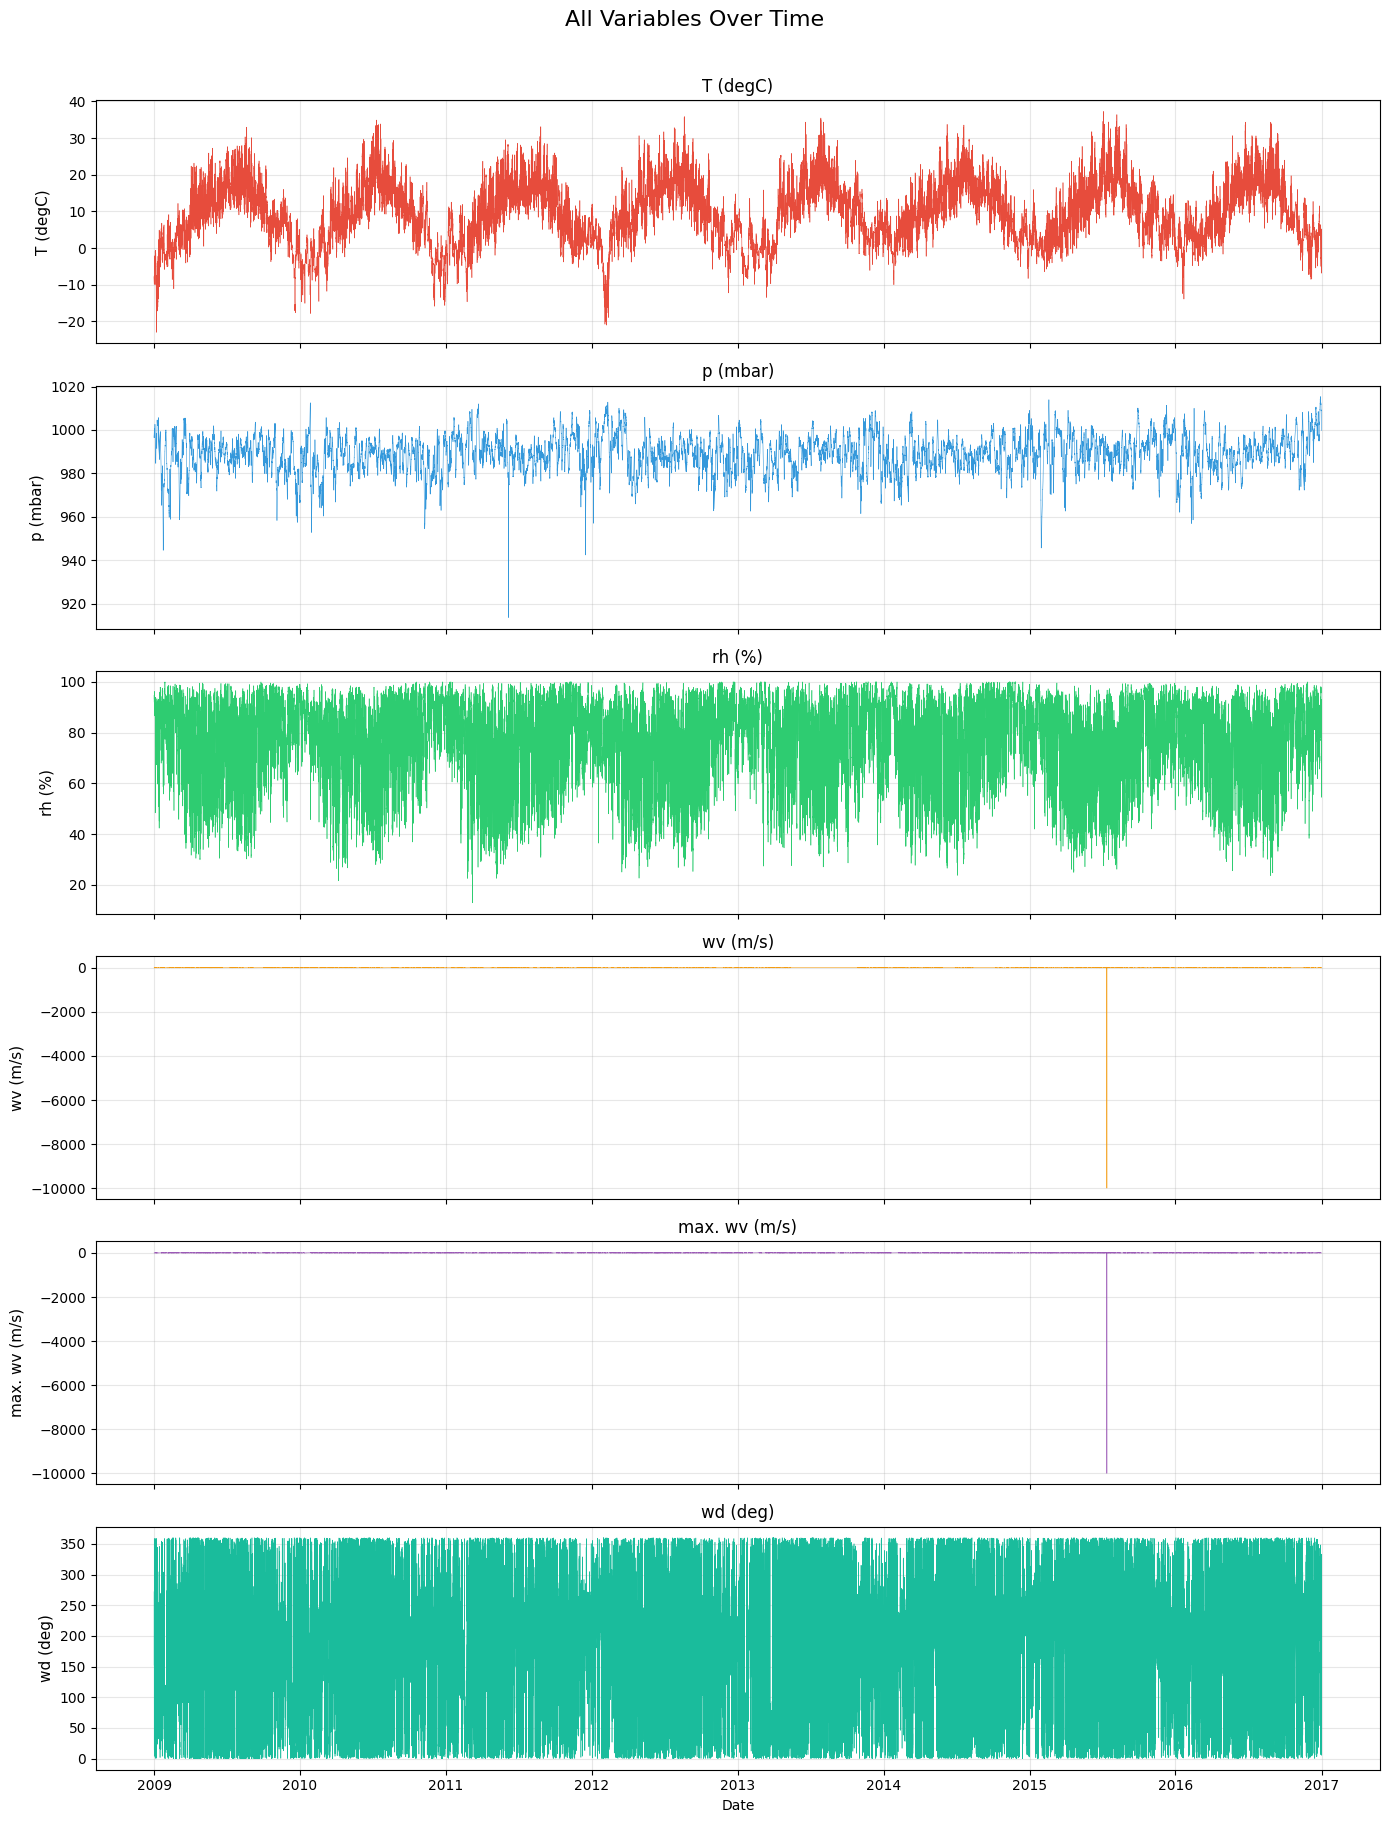

In [7]:
# Plot all input variables as subplots
feature_cols = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(14, 3 * len(feature_cols)), sharex=True)

for i, (col, color) in enumerate(zip(feature_cols, colors)):
    axes[i].plot(df.index, df[col], linewidth=0.4, color=color)
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_title(col, fontsize=12)

axes[-1].set_xlabel('Date')
fig.suptitle('All Variables Over Time', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Observations:
# - Temperature and humidity show clear seasonal patterns
# - Pressure is relatively stable with some short-term weather events
# - Wind speed has sporadic spikes (potential outliers)
# - Wind direction spans 0-360° as expected


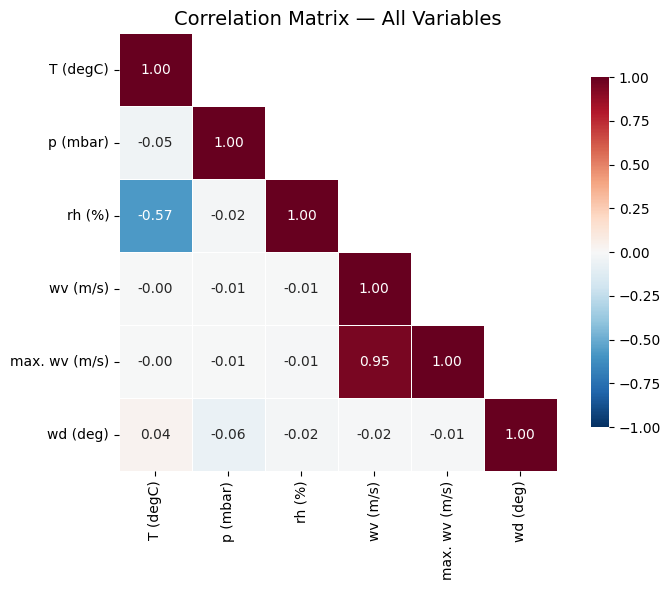

Correlations with Temperature T (degC):
wd (deg)         0.038732
max. wv (m/s)   -0.002871
wv (m/s)        -0.004689
p (mbar)        -0.045375
rh (%)          -0.572416


In [8]:
# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — All Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Identify correlations with temperature
print("Correlations with Temperature T (degC):")
print(corr_matrix['T (degC)'].drop('T (degC)').sort_values(ascending=False).to_string())

# Discussion:
# - Relative humidity (rh) typically has a strong negative correlation with temperature
# - Pressure may show weak-to-moderate correlation
# - Wind variables tend to be less correlated with temperature
# - Highly correlated features may provide redundant information


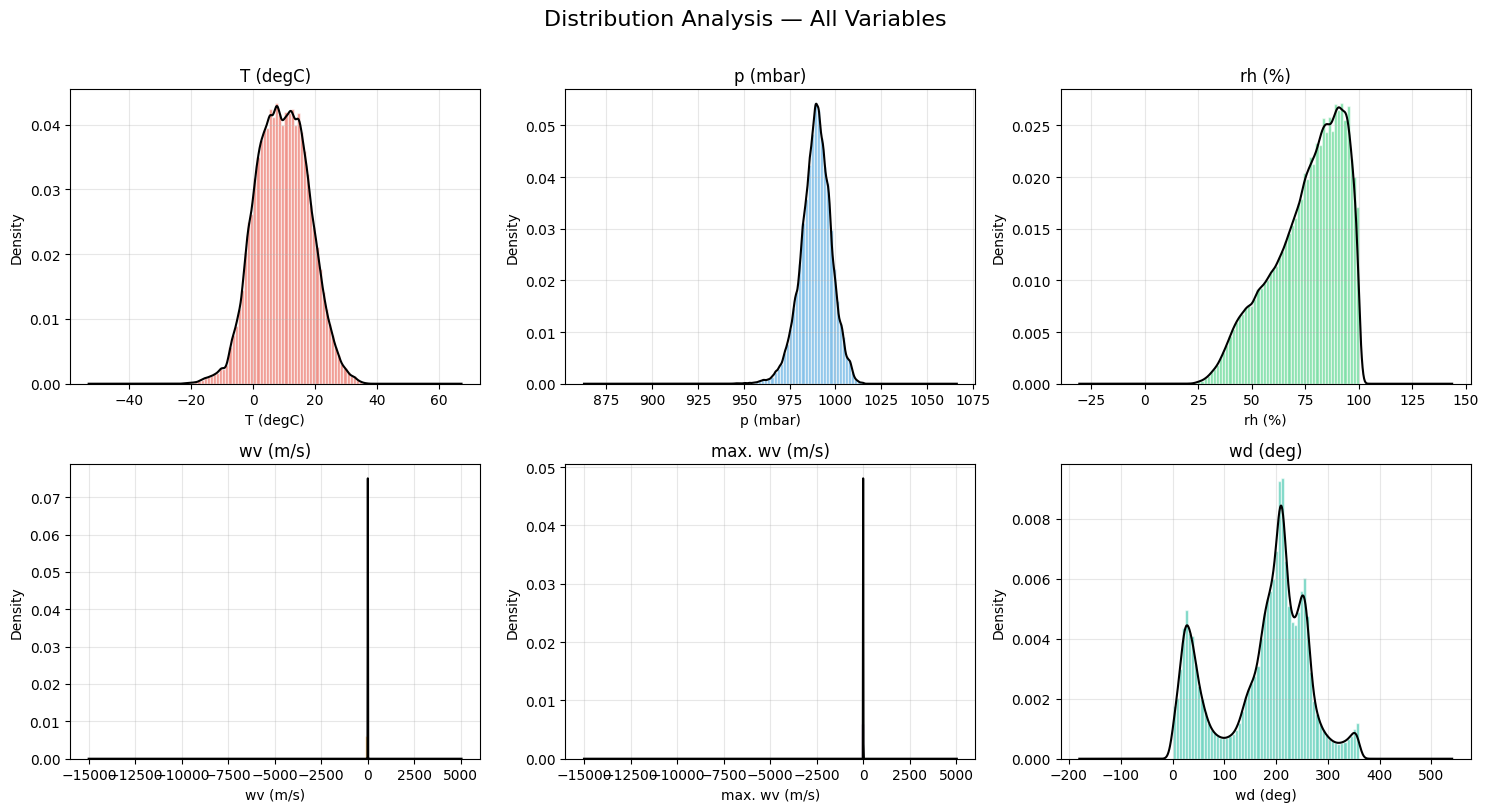

In [9]:
# Histograms + KDE for each variable
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].dropna(), bins=60, density=True, alpha=0.6, color=colors[i], edgecolor='white')
    df[col].dropna().plot.kde(ax=axes[i], color='black', linewidth=1.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].grid(True, alpha=0.3)

fig.suptitle('Distribution Analysis — All Variables', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Observations:
# - Temperature: roughly bimodal (summer vs winter), slight negative skew
# - Pressure: approximately normal, centered around ~990 mbar
# - Humidity: left-skewed, often high values
# - Wind speed: right-skewed with some outliers at high values
# - Wind direction: multimodal (prevailing wind directions)


---
## 4. Data Preprocessing

Prepare the data for modelling: sub-sampling, temporal covariates, normalization, and splitting.

### 4.1 Sub-sampling

The original data is recorded every 10 minutes. Sub-sample to reduce computational cost.

In [ ]:
# Step 1: Remove duplicate timestamps (keep first)
print(f"Duplicate timestamps before cleaning: {df.index.duplicated().sum()}")
df_clean = df[~df.index.duplicated(keep='first')].copy()
print(f"Records after removing duplicates: {len(df_clean)} (removed {len(df) - len(df_clean)})")

# Step 2: Fix erroneous wind speed values (-9999 sentinel values)
def fix_negative_wind_speed(df, column):
    """Replace negative wind speeds with the median of same time-of-day values."""
    negative_mask = df[column] < 0
    n_negative = negative_mask.sum()
    print(f"  Fixing {n_negative} negative values in '{column}'")
    if n_negative == 0:
        return df
    for idx in df[negative_mask].index:
        time_of_day = idx.time()
        same_time_vals = df[df.index.time == time_of_day][column]
        median_val = same_time_vals[same_time_vals >= 0].median()
        df.at[idx, column] = median_val
    return df

df_clean = fix_negative_wind_speed(df_clean, 'wv (m/s)')
df_clean = fix_negative_wind_speed(df_clean, 'max. wv (m/s)')
print(f"  Remaining negative wv: {(df_clean['wv (m/s)'] < 0).sum()}")
print(f"  Remaining negative max wv: {(df_clean['max. wv (m/s)'] < 0).sum()}")

# Step 3: Resample to hourly intervals
df_hourly = df_clean.resample('1h').mean()
print(f"\nOriginal shape (10-min):  {df_clean.shape}")
print(f"Resampled shape (hourly): {df_hourly.shape}")
print(f"Reduction factor: {len(df_clean) / len(df_hourly):.1f}x")

# Handle any NaN introduced by resampling
nan_count = df_hourly.isnull().sum().sum()
print(f"\nNaN after resampling: {nan_count}")
if nan_count > 0:
    df_hourly = df_hourly.interpolate(method='linear')
    print(f"NaN after interpolation: {df_hourly.isnull().sum().sum()}")

# Verify regular intervals
time_diffs = df_hourly.index.to_series().diff().iloc[1:]
irregular = time_diffs[time_diffs != pd.Timedelta(hours=1)]
print(f"Irregular intervals: {len(irregular)}")

df_subsampled = df_hourly.copy()
print(f"\nFinal sub-sampled shape: {df_subsampled.shape}")
df_subsampled.head(10)


Duplicate timestamps before cleaning: 327
Records after removing duplicates: 420224 (removed 327)
  Fixing 18 negative values in 'wv (m/s)'
  Fixing 20 negative values in 'max. wv (m/s)'
  Remaining negative wv: 0
  Remaining negative max wv: 0

Original shape (10-min):  (420224, 6)
Resampled shape (hourly): (70129, 6)
Reduction factor: 6.0x

NaN after resampling: 528
NaN after interpolation: 0
Irregular intervals: 0

Final sub-sampled shape: (70129, 6)


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333
2009-01-01 05:00:00,-9.716667,997.510000,92.383333,0.325000,0.813333,118.886667
2009-01-01 06:00:00,-9.298333,997.955000,92.483333,0.818333,1.501667,145.235000
2009-01-01 07:00:00,-8.543333,998.685000,93.050000,1.405000,1.941667,326.700000
2009-01-01 08:00:00,-7.926667,999.376667,92.616667,0.506667,0.876667,219.566667


### 4.2 Temporal Covariates

Engineer time-based features. Use **cyclic encoding** (sin/cos) for periodic features.

In [ ]:
# Temporal Covariates (Cyclic Encoding)
# Cyclic encoding preserves the circular nature of time:
#   - Hour 23 is close to hour 0 (not far apart like with raw integers)
#   - December is close to January

# Hour of day (period = 24)
df_subsampled['hour_sin'] = np.sin(2 * np.pi * df_subsampled.index.hour / 24)
df_subsampled['hour_cos'] = np.cos(2 * np.pi * df_subsampled.index.hour / 24)

# Day of year (period = 365.25, accounts for leap years)
df_subsampled['day_of_year_sin'] = np.sin(2 * np.pi * df_subsampled.index.dayofyear / 365.25)
df_subsampled['day_of_year_cos'] = np.cos(2 * np.pi * df_subsampled.index.dayofyear / 365.25)

# Day of week (period = 7)
df_subsampled['day_of_week_sin'] = np.sin(2 * np.pi * df_subsampled.index.dayofweek / 7)
df_subsampled['day_of_week_cos'] = np.cos(2 * np.pi * df_subsampled.index.dayofweek / 7)

print(f"Shape after adding temporal covariates: {df_subsampled.shape}")
print(f"Columns: {list(df_subsampled.columns)}")
df_subsampled.head()


Shape after adding temporal covariates: (70129, 12)
Columns: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos']


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg),hour_sin,hour_cos,day_of_year_sin,day_of_year_cos,day_of_week_sin,day_of_week_cos
Date Time,,,,,,,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000,0.000000,1.000000,0.017202,0.999852,0.433884,-0.900969
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667,0.258819,0.965926,0.017202,0.999852,0.433884,-0.900969
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667,0.500000,0.866025,0.017202,0.999852,0.433884,-0.900969
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333,0.707107,0.707107,0.017202,0.999852,0.433884,-0.900969
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333,0.866025,0.500000,0.017202,0.999852,0.433884,-0.900969


### 4.3 Train / Validation / Test Split

Use a **chronological split** (no shuffling for time series!).

- **Test set must remain UNTOUCHED** until final evaluation.
- Validation set is used for evolutionary fitness evaluation.

Train: 49,090 samples (70.0%) | 2009-01-01 00:00:00 → 2014-08-08 09:00:00
Val:   10,519 samples (15.0%) | 2014-08-08 10:00:00 → 2015-10-20 16:00:00
Test:  10,520 samples (15.0%) | 2015-10-20 17:00:00 → 2017-01-01 00:00:00


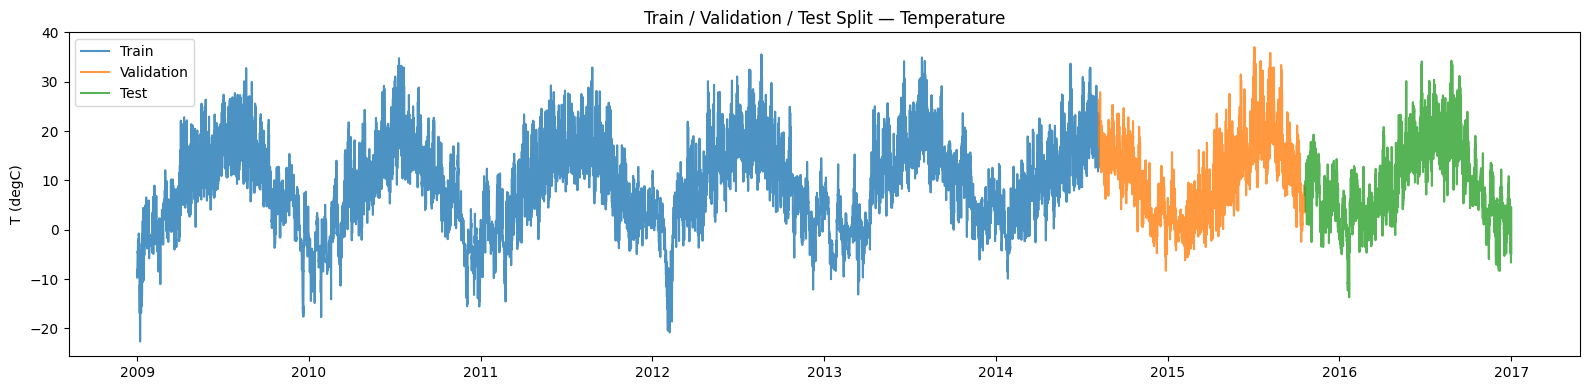

In [ ]:
# 70% train, 15% validation, 15% test — NO SHUFFLING for time series!
n = len(df_subsampled)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_subsampled.iloc[:train_end].copy()
df_val   = df_subsampled.iloc[train_end:val_end].copy()
df_test  = df_subsampled.iloc[val_end:].copy()

print(f"Train: {len(df_train):,} samples ({len(df_train)/n*100:.1f}%) | "
      f"{df_train.index[0]} → {df_train.index[-1]}")
print(f"Val:   {len(df_val):,} samples ({len(df_val)/n*100:.1f}%) | "
      f"{df_val.index[0]} → {df_val.index[-1]}")
print(f"Test:  {len(df_test):,} samples ({len(df_test)/n*100:.1f}%) | "
      f"{df_test.index[0]} → {df_test.index[-1]}")

# Quick visualization of the split
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_train.index, df_train[TARGET_COL], label='Train', alpha=0.8)
ax.plot(df_val.index,   df_val[TARGET_COL],   label='Validation', alpha=0.8)
ax.plot(df_test.index,  df_test[TARGET_COL],  label='Test', alpha=0.8)
ax.set_title('Train / Validation / Test Split — Temperature')
ax.set_ylabel('T (degC)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.4 Normalization / Scaling

**IMPORTANT:** Fit the scaler on **training data only** to avoid data leakage.

In [ ]:
# StandardScaler: zero mean, unit variance
# FIT ON TRAINING DATA ONLY to prevent data leakage

scaler = StandardScaler()

train_scaled = scaler.fit_transform(df_train.values)
val_scaled   = scaler.transform(df_val.values)
test_scaled  = scaler.transform(df_test.values)

# Find target column index (for windowing later)
ALL_COLS = list(df_subsampled.columns)
TARGET_IDX = ALL_COLS.index(TARGET_COL)

print(f"Scaler fitted on training data ({len(df_train)} samples)")
print(f"Feature columns ({len(ALL_COLS)}): {ALL_COLS}")
print(f"Target column: '{TARGET_COL}' at index {TARGET_IDX}")
print(f"\nScaled shapes — Train: {train_scaled.shape}, Val: {val_scaled.shape}, Test: {test_scaled.shape}")


Scaler fitted on training data (49090 samples)
Feature columns (12): ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos']
Target column: 'T (degC)' at index 0

Scaled shapes — Train: (49090, 12), Val: (10519, 12), Test: (10520, 12)


---
## 5. Windowing & DataLoaders

Create supervised learning samples using sliding windows:

$$\mathbf{X}_{t-L+1:t} \longrightarrow \mathbf{y}_{t+1:t+H}$$

- **L** = lookback window length (number of past time steps)
- **H** = forecast horizon (number of future time steps to predict)
- **X** = multivariate input (all meteorological variables)
- **y** = univariate output (temperature only)

In [ ]:
# Defaults — will be optimized by evolutionary algorithm in Section 7 
LOOKBACK   = 72   # 72 hours = 3 days of history
HORIZON    = 24   # 24 hours = 1 day forecast
BATCH_SIZE = 64

print(f"Lookback:   {LOOKBACK} hours ({LOOKBACK/24:.1f} days)")
print(f"Horizon:    {HORIZON} hours ({HORIZON/24:.1f} days)")
print(f"Batch size: {BATCH_SIZE}")


Lookback:   72 hours (3.0 days)
Horizon:    24 hours (1.0 days)
Batch size: 64


In [ ]:
# Window Function 
def create_windows(data, target_idx, lookback, horizon):
    """
    Create sliding window samples for multi-step forecasting.

    Args:
        data: numpy array of shape (timesteps, features)
        target_idx: column index of the target variable
        lookback: L — number of past time steps as input
        horizon: H — number of future time steps to predict

    Returns:
        X: shape (num_samples, lookback, num_features)
        y: shape (num_samples, horizon)
    """
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i - lookback:i, :])          # all features
        y.append(data[i:i + horizon, target_idx])   # target only
    return np.array(X), np.array(y)


In [ ]:
# Create Windowed Datasets 
X_train, y_train = create_windows(train_scaled, TARGET_IDX, LOOKBACK, HORIZON)
X_val,   y_val   = create_windows(val_scaled,   TARGET_IDX, LOOKBACK, HORIZON)
X_test,  y_test  = create_windows(test_scaled,  TARGET_IDX, LOOKBACK, HORIZON)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (48995, 72, 12), y_train: (48995, 24)
X_val:   (10424, 72, 12),   y_val:   (10424, 24)
X_test:  (10425, 72, 12),  y_test:  (10425, 24)


In [ ]:
# PyTorch Dataset & DataLoaders 
class TimeSeriesDataset(Dataset):
    """Custom Dataset for time series windowed data."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val, y_val)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verify a batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {X_batch.shape}")  # (batch_size, lookback, features)
print(f"Batch y shape: {y_batch.shape}")  # (batch_size, horizon)
print(f"\nDataLoaders ready:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")


Batch X shape: torch.Size([64, 72, 12])
Batch y shape: torch.Size([64, 24])

DataLoaders ready:
  Train: 766 batches
  Val:   163 batches
  Test:  163 batches


---
## 6. Baseline Models

Train at least one baseline architecture (GRU or Transformer) from the mini-project.
This serves as the **reference** for all subsequent improvements.

### 6.1 GRU Baseline

In [18]:
class TimeSeriesGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        '''
        GRU-based model for multi-step time series forecasting.
        Processes the input sequence step-by-step, then uses the final hidden
        state to predict all H future values at once (Direct Multi-Step).
        '''
        super(TimeSeriesGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        gru_out, _ = self.gru(x, h0)
        out = self.fc(gru_out[:, -1, :])
        return out

### 6.2 Transformer Baseline

In [ ]:
#  Positional Encoding for Transformer 
class PositionalEncoding(nn.Module):
    """Sinusoidal Positional Encoding for Transformer models."""
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create sinusoidal positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)  # PE(pos, 2i)
        pe[:, 1::2] = torch.cos(position * div_term)  # PE(pos, 2i+1)

        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)  # not a learnable parameter

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


In [20]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, output_dim, dropout=0.1):
        '''
        Transformer Encoder model for multi-step time series forecasting.
        Processes the entire input sequence in parallel via self-attention, then
        uses the final position's output to predict all H future values at once (Direct Multi-Step).
        '''
        super(TimeSeriesTransformer, self).__init__()
        self.d_model = d_model
        self.input_linear = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 200, d_model))
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_linear(x)
        x = x + self.pos_encoder[:, :seq_len, :]
        x = self.transformer_encoder(x)
        x = x[:, -1, :] 
        out = self.decoder(x)
        
        return out

### 6.3 Training Loop & Utilities

In [ ]:
#  Training function with early stopping 
def train_model(model, train_loader, val_loader, optimizer, criterion,
                num_epochs=100, patience=10, device=DEVICE):
    """
    Train a model with early stopping and track efficiency metrics.
    Returns history dict and best model state_dict.
    """
    history = {'train_loss': [], 'val_loss': [], 'epoch_times': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    total_start = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()

        #  Training step 
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        #  Validation step 
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        epoch_time = time.time() - epoch_start

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epoch_times'].append(epoch_time)

        #  Early stopping 
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            best_epoch = epoch + 1
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or patience_counter == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
                  f"Time: {epoch_time:.1f}s"
                  f"{' ★' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} (best: {best_epoch})")
            break

    total_time = time.time() - total_start
    history['total_time'] = total_time
    history['best_epoch'] = best_epoch
    history['best_val_loss'] = best_val_loss

    # Restore best weights
    model.load_state_dict(best_model_state)
    print(f"\nTraining complete in {total_time:.1f}s | Best epoch: {best_epoch} | Best val loss: {best_val_loss:.6f}")

    return history, best_model_state


In [22]:
# Evaluation function 
def evaluate_model(model, test_loader, criterion, scaler, target_idx, device=DEVICE):
    """
    Evaluate a trained model. Compute MSE, RMSE, MAE, R*2 in original scale.
    """
    model.eval()
    all_preds, all_targets = [], []
    inference_start = time.time() # to calculate the time that the model takes to make predictions on the test set

    with torch.no_grad(): #no gradient calculations so that we can save memory and speed up computations.
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)
            all_preds.append(y_pred.cpu().numpy())
            all_targets.append(y_batch.numpy())

    inference_time = time.time() - inference_start # After the loop, we calculate the total inference time by subtracting the start time from the current time.

    y_pred = np.concatenate(all_preds, axis=0)
    y_true = np.concatenate(all_targets, axis=0)

    # Inverse-transform to original scale (temperature only)
    target_mean = scaler.mean_[target_idx]
    target_std = scaler.scale_[target_idx]
    y_pred_orig = y_pred * target_std + target_mean
    y_true_orig = y_true * target_std + target_mean

    # Compute metrics on original scale
    mse = mean_squared_error(y_true_orig.flatten(), y_pred_orig.flatten())
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_orig.flatten(), y_pred_orig.flatten())
    r2 = r2_score(y_true_orig.flatten(), y_pred_orig.flatten())

    # Scaled-space metrics (for comparison with old report)
    mse_scaled = mean_squared_error(y_true.flatten(), y_pred.flatten())
    mae_scaled = mean_absolute_error(y_true.flatten(), y_pred.flatten())

    results = {
        'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'mse_scaled': mse_scaled, 'mae_scaled': mae_scaled,
        'y_true': y_true_orig, 'y_pred': y_pred_orig,
        'inference_time': inference_time,
        'num_params': sum(p.numel() for p in model.parameters()),
    }

    print(f"Test Results (original scale): MSE={mse:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}")
    print(f"Test Results (scaled space):   MSE={mse_scaled:.5f} | MAE={mae_scaled:.5f}")
    print(f"Inference time: {inference_time:.2f}s | Parameters: {results['num_params']:,}")

    return results


In [23]:
# Plotting functions
def plot_training_history(history, title="Training History"):
    """Plot train and validation loss curves."""
    fig, ax = plt.subplots(figsize=(10, 4))
    history, best_state = history
    ax.plot(history['train_loss'], label='Train Loss', alpha=0.8)
    ax.plot(history['val_loss'], label='Val Loss', alpha=0.8)
    ax.axvline(x=history['best_epoch']-1, color='r', linestyle='--', alpha=0.5, label=f"Best epoch ({history['best_epoch']})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_predictions(y_true, y_pred, title="Predictions vs Actual", n_samples=5):
    """Plot overlay of predicted and actual temperature for random samples."""
    fig, axes = plt.subplots(n_samples, 1, figsize=(14, 3 * n_samples), sharex=True)
    indices = np.random.choice(len(y_true), n_samples, replace=False)

    for ax, idx in zip(axes, sorted(indices)):
        hours = np.arange(y_true.shape[1])
        ax.plot(hours, y_true[idx], 'b-o', label='Actual', markersize=3)
        ax.plot(hours, y_pred[idx], 'r--s', label='Predicted', markersize=3)
        ax.set_ylabel('T (°C)')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_title(f'Sample {idx}', fontsize=9)

    axes[-1].set_xlabel('Forecast Hour')
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


### 6.4 Train & Evaluate Baselines

GRU Parameters: 156,696
Epoch   1/100 | Train: 0.211461 | Val: 0.102540 | Time: 2.6s ★
Epoch   2/100 | Train: 0.100929 | Val: 0.093481 | Time: 2.3s ★
Epoch   3/100 | Train: 0.093682 | Val: 0.086656 | Time: 2.3s ★
Epoch   4/100 | Train: 0.090035 | Val: 0.085540 | Time: 2.2s ★
Epoch   5/100 | Train: 0.087003 | Val: 0.084599 | Time: 2.2s ★
Epoch   6/100 | Train: 0.085035 | Val: 0.083609 | Time: 2.2s ★
Epoch   7/100 | Train: 0.083528 | Val: 0.080509 | Time: 4.0s ★
Epoch  10/100 | Train: 0.079719 | Val: 0.080099 | Time: 2.3s ★
Epoch  11/100 | Train: 0.078622 | Val: 0.078712 | Time: 2.3s ★
Epoch  12/100 | Train: 0.077755 | Val: 0.077428 | Time: 2.3s ★
Epoch  14/100 | Train: 0.075723 | Val: 0.077123 | Time: 2.3s ★
Epoch  15/100 | Train: 0.074749 | Val: 0.075682 | Time: 2.3s ★
Epoch  17/100 | Train: 0.072823 | Val: 0.075077 | Time: 2.4s ★
Epoch  20/100 | Train: 0.070422 | Val: 0.073436 | Time: 4.2s ★
Epoch  27/100 | Train: 0.066040 | Val: 0.071393 | Time: 2.6s ★
Epoch  30/100 | Train: 0.064543

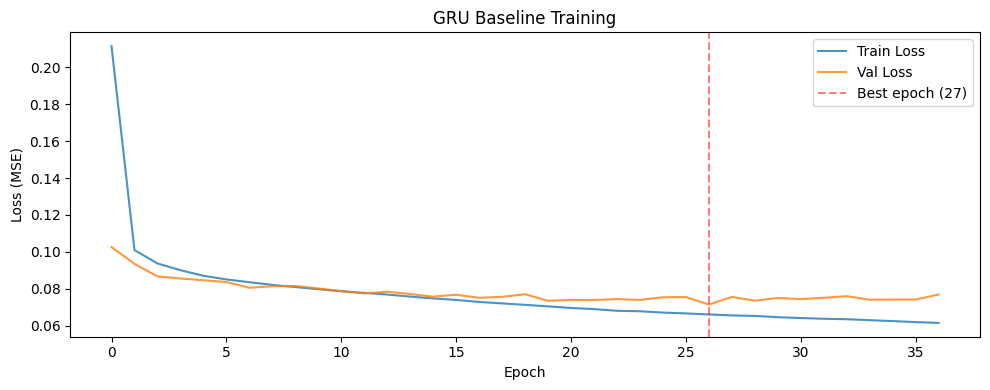

In [24]:
# Train the GRU baseline model
NUM_FEATURES = X_train.shape[2]
MODELS_DIR = "models/"
os.makedirs(MODELS_DIR, exist_ok=True)

gru_model = TimeSeriesGRU(
    input_dim=NUM_FEATURES,
    hidden_dim=128,
    num_layers=2,
    output_dim=HORIZON,
    dropout=0.5
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=1e-4, weight_decay=1e-4)

print(f"GRU Parameters: {sum(p.numel() for p in gru_model.parameters()):,}")
gru_history = train_model(gru_model, train_loader, val_loader, optimizer, criterion,
                          num_epochs=100, patience=10)

torch.save(gru_model.state_dict(), os.path.join(MODELS_DIR, "gru_baseline.pt"))
print(f"Model saved to {MODELS_DIR}gru_baseline.pt")
plot_training_history(gru_history, "GRU Baseline Training")


### Optionally, load GRU instead

In [25]:
# Load pre-trained baseline models instead of training
gru_model = TimeSeriesGRU(input_dim=len(ALL_COLS), hidden_dim=128, num_layers=2, 
                          output_dim=HORIZON, dropout=0.5).to(DEVICE)
gru_model.load_state_dict(torch.load("models/gru_baseline.pt", map_location=DEVICE))

<All keys matched successfully>

Test Results (original scale): MSE=5.2339 | RMSE=2.2878 | MAE=1.7285 | R²=0.9137
Test Results (scaled space):   MSE=0.07003 | MAE=0.19994
Inference time: 0.24s | Parameters: 156,696


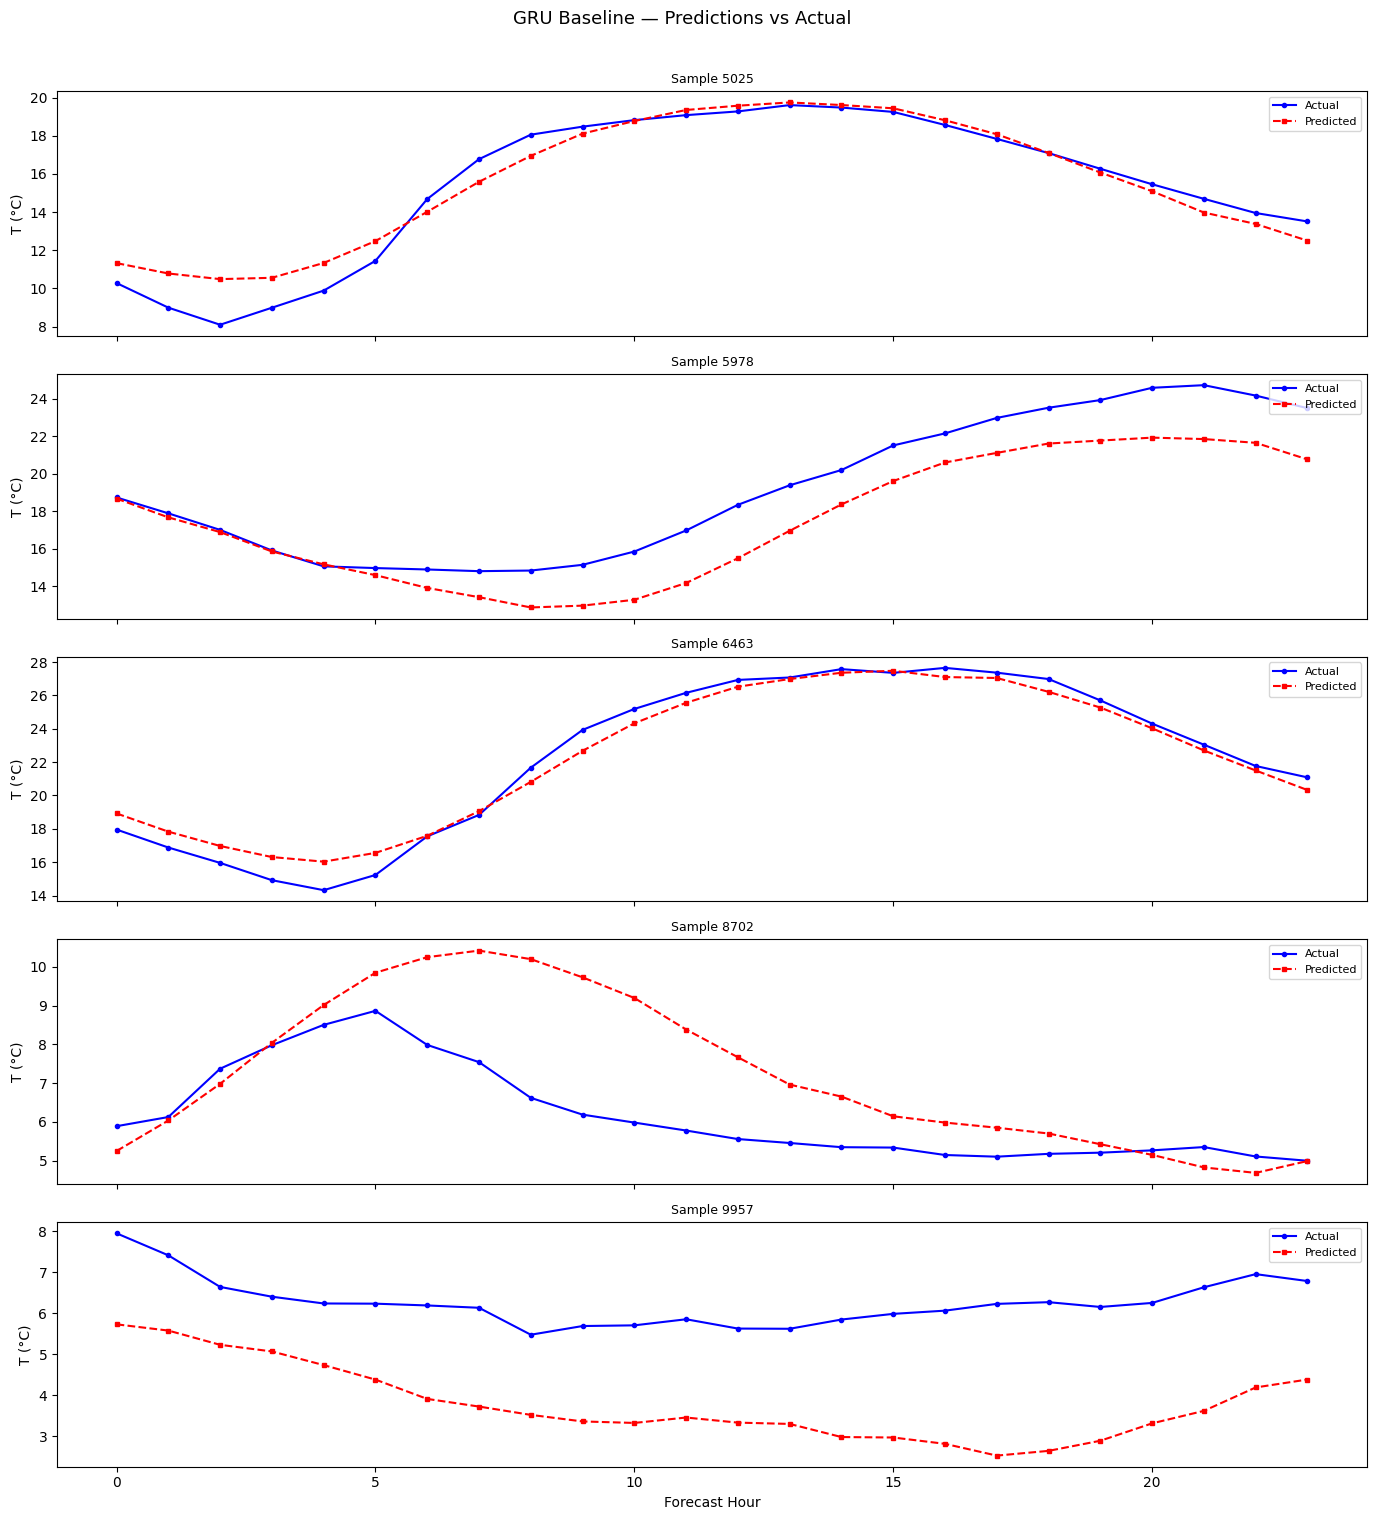

In [ ]:
#  Evaluate GRU Baseline 
gru_results = evaluate_model(gru_model, test_loader, criterion, scaler, TARGET_IDX)
plot_predictions(gru_results['y_true'], gru_results['y_pred'], "GRU Baseline — Predictions vs Actual")


Transformer Parameters: 115,160
Epoch   1/100 | Train: 0.357508 | Val: 0.119527 | Time: 5.2s ★
Epoch   2/100 | Train: 0.143615 | Val: 0.093251 | Time: 5.1s ★
Epoch   3/100 | Train: 0.112193 | Val: 0.085615 | Time: 4.8s ★
Epoch   4/100 | Train: 0.099500 | Val: 0.082589 | Time: 5.4s ★
Epoch   5/100 | Train: 0.093103 | Val: 0.081294 | Time: 7.3s ★
Epoch   6/100 | Train: 0.088763 | Val: 0.080347 | Time: 5.5s ★
Epoch   7/100 | Train: 0.085784 | Val: 0.079264 | Time: 5.1s ★
Epoch   8/100 | Train: 0.083480 | Val: 0.077405 | Time: 5.7s ★
Epoch   9/100 | Train: 0.081326 | Val: 0.076410 | Time: 5.2s ★
Epoch  10/100 | Train: 0.079943 | Val: 0.076859 | Time: 7.4s
Epoch  11/100 | Train: 0.078686 | Val: 0.075599 | Time: 5.6s ★
Epoch  12/100 | Train: 0.077711 | Val: 0.075190 | Time: 5.1s ★
Epoch  14/100 | Train: 0.075854 | Val: 0.075050 | Time: 5.3s ★
Epoch  15/100 | Train: 0.074958 | Val: 0.073968 | Time: 5.7s ★
Epoch  17/100 | Train: 0.073587 | Val: 0.072992 | Time: 5.4s ★
Epoch  20/100 | Train: 0.

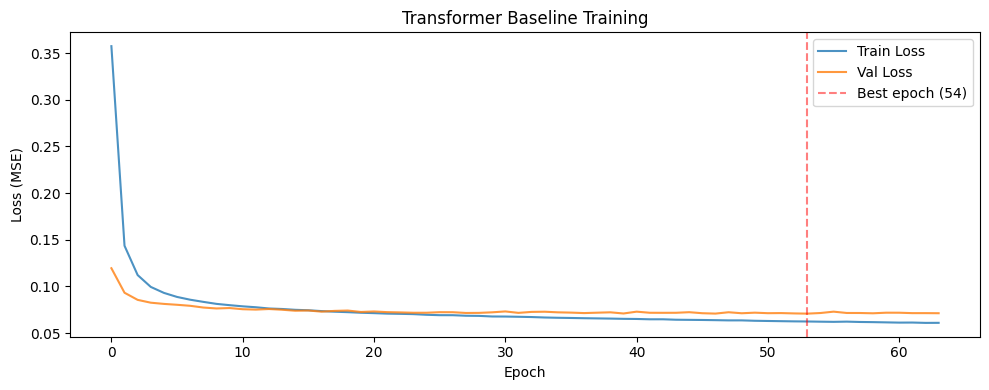

In [27]:
# Train the Transformer baseline model
transformer_model = TimeSeriesTransformer(
    input_dim=NUM_FEATURES,
    d_model=64,
    nhead=4,
    num_layers=2,
    output_dim=HORIZON,
    dropout=0.5
).to(DEVICE)

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-4, weight_decay=1e-4)

print(f"Transformer Parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")
transformer_history = train_model(transformer_model, train_loader, val_loader, optimizer, criterion,
                                  num_epochs=100, patience=10)

torch.save(transformer_model.state_dict(), os.path.join(MODELS_DIR, "transformer_baseline.pt"))
print(f"Model saved to {MODELS_DIR}transformer_baseline.pt")
plot_training_history(transformer_history, "Transformer Baseline Training")


### Optionally, load the Transformer model instead

In [28]:
transformer_model = TimeSeriesTransformer(input_dim=len(ALL_COLS), d_model=64, nhead=4,
                                          num_layers=2, output_dim=HORIZON, dropout=0.5).to(DEVICE)
transformer_model.load_state_dict(torch.load("models/transformer_baseline.pt", map_location=DEVICE))

<All keys matched successfully>

Test Results (original scale): MSE=4.9447 | RMSE=2.2237 | MAE=1.6716 | R²=0.9185
Test Results (scaled space):   MSE=0.06616 | MAE=0.19336
Inference time: 0.31s | Parameters: 115,160


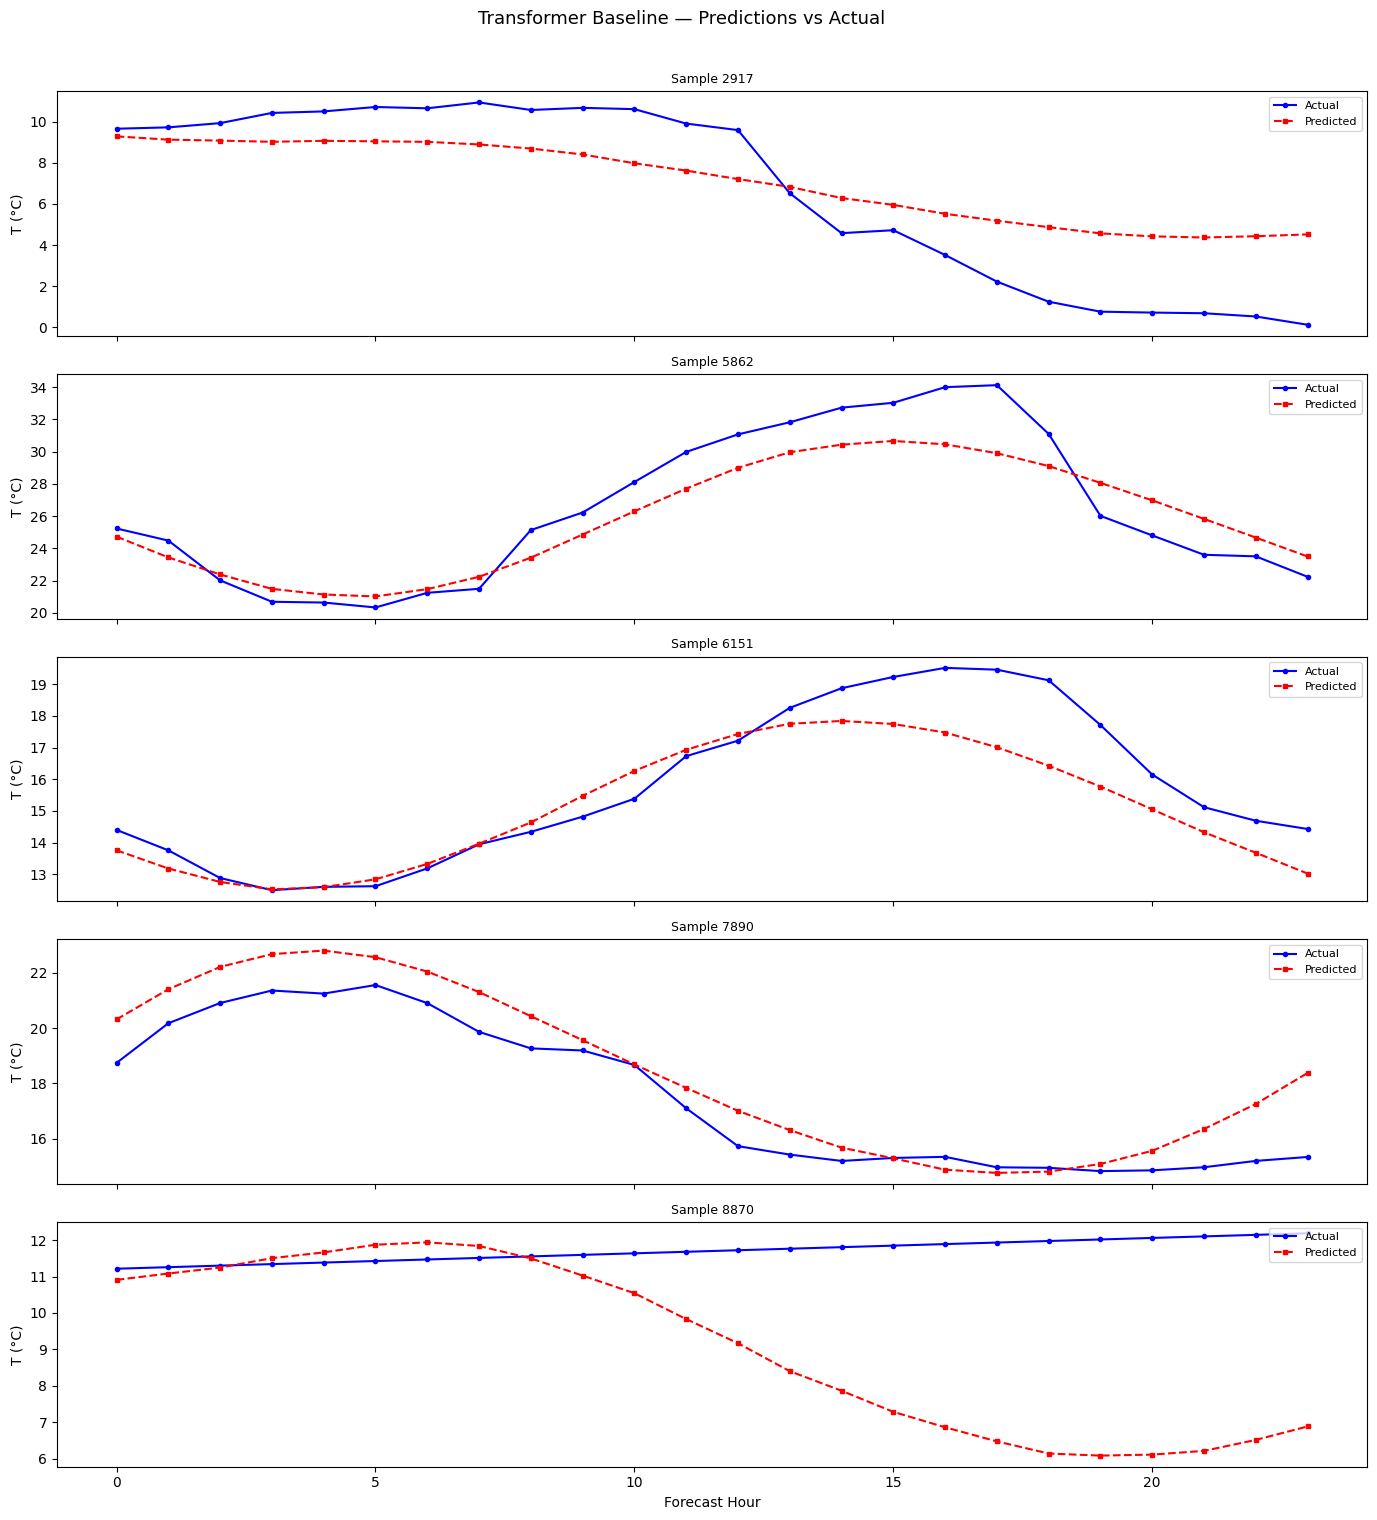


BASELINE COMPARISON
Metric                        GRU  Transformer
--------------------------------------------
MSE                        5.2339       4.9447
RMSE                       2.2878       2.2237
MAE                        1.7285       1.6716
R2                         0.9137       0.9185
MSE (scaled)              0.07003      0.06616
MAE (scaled)              0.19994      0.19336
Parameters                156,696      115,160
Inference (s)                0.24         0.31


In [ ]:
#  Evaluate Transformer Baseline 

transformer_results = evaluate_model(transformer_model, test_loader, criterion, scaler, TARGET_IDX)
plot_predictions(transformer_results['y_true'], transformer_results['y_pred'], "Transformer Baseline — Predictions vs Actual")

#  Baseline Comparison Summary 
print("\n" + "="*60)
print("BASELINE COMPARISON")
print("="*60)
print(f"{'Metric':<20} {'GRU':>12} {'Transformer':>12}")
print("-"*44)
for m in ['mse', 'rmse', 'mae', 'r2']:
    print(f"{m.upper():<20} {gru_results[m]:>12.4f} {transformer_results[m]:>12.4f}")
print(f"{'MSE (scaled)':<20} {gru_results['mse_scaled']:>12.5f} {transformer_results['mse_scaled']:>12.5f}")
print(f"{'MAE (scaled)':<20} {gru_results['mae_scaled']:>12.5f} {transformer_results['mae_scaled']:>12.5f}")
print(f"{'Parameters':<20} {gru_results['num_params']:>12,} {transformer_results['num_params']:>12,}")
print(f"{'Inference (s)':<20} {gru_results['inference_time']:>12.2f} {transformer_results['inference_time']:>12.2f}")


---
## 7. Evolutionary Optimization

In this section, we implement a custom **Genetic Algorithm (GA)** to automate the search for the optimal forecasting pipeline. 

Given the vast and complex search space of deep learning architectures and time-series configurations, exhaustive methods like Grid Search become computationally prohibitive. Our evolutionary approach mimics natural selection to iteratively evolve a population of candidate models, efficiently navigating the search space to find the global optimum.

### Evolutionary Mechanics
To drive the evolution, we designed the following mechanics:
- **Fitness Evaluation:** The primary metric is the **Mean Squared Error (MSE)** on the validation set. The environment strictly rewards minimization.
- **Selection:** We utilize **Tournament Selection**. By randomly grouping individuals and selecting the one with the lowest MSE, we apply strong selection pressure while preserving enough genetic diversity to avoid premature convergence in local minima.
- **Crossover & Mutation:** A **Uniform Crossover** strategy randomly inherits parameters from two successful parents. A mutation rate is applied to randomly flip genes, ensuring the exploration of unseen architectures.
- **Tracking & Elitism:** The algorithm dynamically tracks and saves the weights (`.pt`) and configurations (`.txt`) of the top-performing individuals of each generation, ensuring the best overall models are ready for final testing.


### 7.1 Genotype Representation

In the context of our Genetic Algorithm, the **genotype** (or chromosome) represents a single, fully defined forecasting pipeline. It is encoded computationally as a key-value dictionary, where each "gene" corresponds to a specific hyperparameter or architectural decision.

To ensure a robust evolutionary process and prevent the algorithm from testing impossible architectures, we strictly bounded our **Search Space**. The genes are divided into the following categories:

**1. Data & Windowing Genes:**
* `lookback` (Discrete): The input sequence length in hours (e.g., 24, 48, 72, 120). This dictates how much historical context the model sees.

**2. Architectural Genes (Categorical & Boolean):**
* `model_type` (Categorical): The core sequence modeling architecture (`'gru'` or `'transformer'`).
* `bidirectional` (Boolean): Defines if the GRU layers process the sequence in both temporal directions (`True`, `False`).

**3. Capacity Genes (Discrete Integer):**
* `num_layers` (Discrete): The depth of the neural network (e.g., 1, 2, 3, 4).
* `hidden_size` (Discrete): The width or dimensionality of the hidden states (e.g., 32, 64, 128, 256).
* `nhead` & `dim_feedforward` (Discrete): Specific parameters activated only when a Transformer gene is selected.

**4. Optimization & Regularization Genes:**
* `learning_rate` (Continuous/Discrete Float): Controls the step size during gradient descent optimization (e.g., 0.001, 0.005).
* `dropout` (Continuous Float): The probability of zeroing elements to prevent overfitting (e.g., 0.1, 0.2, 0.3).
* `batch_size` (Discrete): The number of samples processed before updating internal model parameters.

By representing the pipeline in this structured format, the algorithm can easily mutate individual properties (e.g., flipping a GRU to a Transformer) or cross over successful genes between two high-performing parent models without breaking the PyTorch initialization.

In [30]:
SEARCH_SPACE = {
    # Windowing parameters:
    'lookback':        [24, 48, 72, 96, 120, 168],  # hours
    'horizon':         [6, 12, 24, 48],              # hours

    # Type of model and architecture:
    'model_type':      ['gru', 'transformer'],
    'hidden_size':     [32, 64, 128, 256],
    'num_layers':      [1, 2, 3, 4],
    'dropout':         [0.0, 0.1, 0.2, 0.3, 0.5],

    # For GRU:
    'bidirectional':   [True, False],

    # For transformer:
    'nhead':           [2, 4, 8],
    'dim_feedforward': [64, 128, 256],

    # Lr and Batch size:
    'learning_rate':   [1e-4, 5e-4, 1e-3, 5e-3], 
    'batch_size':      [32, 64, 128],
}



### Search Space Justification

**Evolutionary Search Space Configuration**

| Component | Gene (Key) | Range / Options | Technical Justification |
| :--- | :--- | :--- | :--- |
| **Temporal Structure** | `lookback` | $[24, 168]$ hours | Captures short-term (1 day) up to long-term (1 week) dependencies. |
| | `horizon` | $[6, 48]$ hours | Tests model robustness across different prediction lengths (6h to 2 days). |
| **Architecture** | `model_type` | `['GRU', 'Transformer']` | Evaluates sequential processing vs. parallel self-attention mechanisms. |
| | `hidden_size` | $[32, 256]$ | Controls representational capacity; balances underfitting vs. overfitting. |
| | `num_layers` | $[1, 4]$ | Determines depth to shape gradient flow and feature abstraction. |
| **Regularization** | `dropout` | $[0.0, 0.5]$ | Essential for generalization; prevents co-adaptation of neurons. |
| **GRU Specifics** | `bidirectional` | `[True, False]` | Allows capturing patterns in both forward and backward temporal directions. |
| **Transf. Specifics**| `nhead` | $\{2, 4, 8\}$ | Defines the granularity of the multi-head attention mechanism. |
| | `dim_feedforward`| $[64, 256]$ | Adjusts the internal complexity of the Transformer's pointwise MLP. |
| **Training Dynamics**| `learning_rate` | $[10^{-4}, 5 \times 10^{-3}]$ | Critical for convergence stability and optimization speed. |
| | `batch_size` | $\{32, 64, 128\}$ | Affects gradient noise and training throughput on GPU hardware. |

### Genotype Representation

Each individual in the population is represented as a **dictionary**, acting as a **Hybrid Genotype**. This representation serves several strategic purposes in the Deep Learning pipeline:

* **Hybrid Encoding:** By using a dictionary, we can co-optimize continuous (learning rate, dropout), discrete (layers, hidden units), and categorical (model type) genes within a single individual.
* **Genotype-to-Phenotype Mapping:** The dictionary acts as a structural "blueprint" (Genotype). It is easily mapped to the actual trained Neural Network (Phenotype) by passing the dictionary keys as arguments to the model builder.
* **Interpretability:** Unlike flat lists or bitstrings, dictionaries provide clear semantic meaning for each gene, making the evolutionary process easier to debug and analyze.
* **Search Space Scalability:** This format allows us to define clear constraints (min/max values) for each key, ensuring that mutation and crossover operators always produce valid, trainable models.


### 7.2 Create Population

With the search space formally defined, the next step is to instantiate the initial population (Generation 0). 

The initial population serves as the foundational gene pool for the entire evolutionary process. To ensure a broad and unbiased exploration of the search space, these first-generation individuals are generated stochastically. 

For each of the $N$ individuals in the population (where $N$ is our defined `pop_size`), the algorithm constructs a genotype by uniformly sampling a random value for every gene from its allowed bounds or categorical options. 

This random initialization is a critical design choice. By scattering the initial candidate models across the optimization landscape, mixing different baseline architectures, sequence lengths, and capacities, we guarantee maximum **genetic diversity**. This wide initial variance is essential to prevent the algorithm from becoming trapped in a suboptimal local minimum early in the run, providing a rich pool of traits for the crossover and selection mechanisms to evaluate.

In [ ]:
def create_individual():
    """Randomly sample a configuration from the search space to create an individual."""
    individual = { #random choices for each hyperparameter from the defined search space
        'lookback': np.random.choice(SEARCH_SPACE['lookback']),
        'horizon': np.random.choice(SEARCH_SPACE['horizon']),
        'model_type': np.random.choice(SEARCH_SPACE['model_type']),
        'hidden_size': np.random.choice(SEARCH_SPACE['hidden_size']),
        'num_layers': np.random.choice(SEARCH_SPACE['num_layers']),
        'dropout': np.random.choice(SEARCH_SPACE['dropout']),
        'bidirectional': np.random.choice(SEARCH_SPACE['bidirectional']),
        'nhead': np.random.choice(SEARCH_SPACE['nhead']),
        'dim_feedforward': np.random.choice(SEARCH_SPACE['dim_feedforward']),
        'learning_rate': np.random.choice(SEARCH_SPACE['learning_rate']),
        'batch_size': np.random.choice(SEARCH_SPACE['batch_size']),
    }
    return individual

def create_population(pop_size):
    """Create an initial population of individuals."""
    return [create_individual() for _ in range(pop_size)]


Population = []
Individual = None
pop_size = 30
Population = create_population(pop_size)
print(f"Created initial population of {len(Population)} individuals.")
print("Sample individual configuration:")
print("=" * 30)


print(f"{'GENE':<20} | {'VALUE':<15}")
print("-" * 38)
for key, value in Population[0].items():
    print(f"{key:<20} | {str(value):<15}")


Created initial population of 30 individuals.
Sample individual configuration:
GENE                 | VALUE          
--------------------------------------
lookback             | 72             
horizon              | 6              
model_type           | gru            
hidden_size          | 32             
num_layers           | 2              
dropout              | 0.2            
bidirectional        | False          
nhead                | 2              
dim_feedforward      | 64             
learning_rate        | 0.005          
batch_size           | 32             


### 7.3 Mutation and Crossover

Once the most promising parents are selected via the tournament, the algorithm employs two genetic operators—**Crossover** and **Mutation**—to breed the next generation of forecasting models. These operators are responsible for exploiting known good configurations while continuously exploring new areas of the search space.

**1. Uniform Crossover (Recombination)**
We implemented a **Uniform Crossover** strategy with a crossover rate of $0.5$ ($50\%$). Unlike single-point or two-point crossover (which assume a spatial relationship between adjacent genes), uniform crossover evaluates each gene independently. 

For every hyperparameter in the offspring's genotype, a "coin is flipped" to decide whether it inherits the value from Parent A or Parent B. This is particularly effective for our dictionary-based representation, as it allows the algorithm to seamlessly combine, for instance, a highly successful windowing strategy (`lookback`, `horizon`) from one parent with an optimized architectural topology (`hidden_size`, `num_layers`) from another, without positional bias.

**2. Mutation**
To prevent the population from converging too quickly on a local minimum (premature convergence), we introduce a **Mutation** operator with a rate of $0.1$ ($10\%$). 

After crossover, every single gene in the offspring has a $10\%$ probability of mutating. If a mutation triggers, the gene's current value is discarded and replaced with a newly sampled random value from its defined search space bounds. This stochastic "random reset" ensures that genetic diversity is maintained throughout the generations, allowing the algorithm to discover novel architectural combinations that might not have existed in the initial Generation 0 pool.

In [32]:
def mutate(individual, mutation_rate=0.1):
    """Randomly mutate an individual's genes with a given mutation rate."""
    for gene in individual.keys():
        if np.random.rand() < mutation_rate:
            if gene in ['lookback', 'horizon', 'hidden_size', 'num_layers', 'nhead', 'dim_feedforward', 'batch_size']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['model_type']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['dropout']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['bidirectional']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
            elif gene in ['learning_rate']:
                individual[gene] = np.random.choice(SEARCH_SPACE[gene])
    return individual
    


In [ ]:
def uniform_crossover(parent1, parent2):
    """uniform crossover: For each gene, randomly select from one of the two parents with equal probability."""
    child = {}
    for key in parent1.keys():
        if random.random() < 0.5:
            child[key] = parent1[key]
        else:
            child[key] = parent2[key]
    return child

def single_point_crossover(parent1, parent2):
    """ Single-point crossover: Choose a random crossover point and take genes from one parent up to that point, then from the other parent after that point."""
    child = {}
    keys = list(parent1.keys())
    
    # random crossover point between 1 and len(keys)-1 to ensure we get at least one gene from each parent
    crossover_point = random.randint(1, len(keys) - 1)
    
    for i, key in enumerate(keys):
        if i < crossover_point:
            child[key] = parent1[key]
        else:
            child[key] = parent2[key]
    return child

def create_next_population(parents, pop_size, crossover_rate=0.5, mutation_rate=0.1, crossover_choice='uniform'):
    """Create the next generation population through crossover and mutation."""
    next_population = []
    
    while len(next_population) < pop_size:
        parent1, parent2 = random.sample(parents, 2)
        
        if np.random.rand() < crossover_rate:
            if crossover_choice == 'uniform':
                child = uniform_crossover(parent1, parent2)
            elif crossover_choice == 'single_point':
                child = single_point_crossover(parent1, parent2)
            else:
                raise ValueError(f"Método de crossover desconhecido: {crossover_choice}")
        else:
            child = parent1.copy()  
        
        # The mutation is applied to the child after crossover, regardless of whether crossover occurred or not. 
        child = mutate(child, mutation_rate)
        next_population.append(child)
    
    return next_population

In [34]:
def select_parents(population, fitnesses, num_parents=10):
    """
    Selects parents using Tournament Selection, based ONLY on MSE.
    The goal is to minimize the error. Inference time is ignored in selection.
    """
    selected = []
    for _ in range(num_parents):
        # Choose 5 random individuals for the tournament
        tournament = np.random.choice(len(population), size=5, replace=False)
        tournament_fitnesses = [fitnesses[i] for i in tournament]

        # The winner is strictly the one with the LOWEST MSE (argmin)
        winner_idx = tournament[np.argmin(tournament_fitnesses)]
        selected.append(population[winner_idx])
    return selected

### 7.4 Fitness Function

In any evolutionary algorithm, the fitness function acts as the environment that determines the survivability of an individual. For our temperature forecasting pipeline, the primary fitness metric is the **Mean Squared Error (MSE)**. The goal of the algorithm is strictly minimization: individuals with a lower MSE possess higher fitness.

**Strict Validation-Only Evaluation**
A fundamental and non-negotiable constraint of our implementation is that the fitness evaluation is computed **exclusively on the validation set**. 

Under no circumstances is the evolutionary algorithm allowed to access the test set during the hyperparameter search. If the EA were allowed to evaluate models on the test set to guide its selection, it would lead to severe *hyperparameter overfitting* (data leakage). The EA would essentially "memorize" the test data through architectural tweaks, completely invalidating any claims about the final model's real-world generalization capabilities. The test set remains locked and unseen until the final best-overall model is selected for the ultimate evaluation.

**Comprehensive Profiling**
While MSE is the sole metric driving the evolutionary selection pressure (in the tournament), our evaluation function is designed to act as a complete profiler. Alongside the MSE, the function extracts and records:
1. **Inference Time:** The time required for the model to predict the future horizon.
2. **Model Complexity:** The total number of trainable parameters.

Although these secondary metrics do not influence survival, ensuring the algorithm prioritizes pure predictive accuracy over speed during the search phase, they are rigorously logged. This allows us to perform a detailed *Accuracy vs. Efficiency* trade-off analysis in the final stages of the project.

In [35]:
def import_parameters(individual):
    """Extract and cast parameters from the individual's configuration."""
    
    # What is int needs to be told to be int
    lookback = int(individual['lookback'])
    horizon = int(individual['horizon'])
    hidden_size = int(individual['hidden_size'])
    num_layers = int(individual['num_layers'])
    nhead = int(individual['nhead'])
    dim_feedforward = int(individual['dim_feedforward'])
    batch_size = int(individual['batch_size'])
    
    # Same for float
    dropout = float(individual['dropout'])
    learning_rate = float(individual['learning_rate'])
    
    # And for boolean
    bidirectional = bool(individual['bidirectional'])
    
    # and for string (model type)
    model_type = str(individual['model_type'])

    return {
        'lookback': lookback,
        'horizon': horizon,
        'model_type': model_type,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'dropout': dropout,
        'bidirectional': bidirectional,
        'nhead': nhead,
        'dim_feedforward': dim_feedforward,
        'learning_rate': learning_rate,
        'batch_size': batch_size
    }

def evaluate_individual(individual):
    """Evaluate an individual's configuration by training and validating a model, returning fitness and efficiency metrics."""
    params = import_parameters(individual) #params is a dict so we can get the key and value in a loop to print them or use them
    print(f"Evaluating individual with parameters:")
    for key, value in params.items(): # .items() its what allows us to loop through the dict and get the key and value
        print(f"  {key}: {value}")

    # Create windowed datasets based on lookback and horizon
    lookback = params['lookback']
    horizon = params['horizon']
    X_train, y_train = create_windows(train_scaled, TARGET_IDX, lookback, horizon)
    X_val, y_val = create_windows(val_scaled, TARGET_IDX, lookback, horizon)
    X_test, y_test = create_windows(test_scaled, TARGET_IDX, lookback, horizon)

    # Create DataLoaders
    batch_size = params['batch_size']
    train_dataset = TimeSeriesDataset(X_train, y_train)
    val_dataset = TimeSeriesDataset(X_val, y_val)
    test_dataset = TimeSeriesDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    

    # Initialize model based on model_type
    input_dim = X_train.shape[2]
    if params['model_type'] == 'gru':
        model = TimeSeriesGRU(
            input_dim=input_dim,
            hidden_dim=params['hidden_size'],
            num_layers=params['num_layers'],
            output_dim=horizon,
            dropout=params['dropout']
        ).to(DEVICE)
    elif params['model_type'] == 'transformer':
        model = TimeSeriesTransformer(
            input_dim=input_dim,
            d_model=params['hidden_size'],
            nhead=params['nhead'],
            num_layers=params['num_layers'],
            output_dim=horizon,
            dropout=params['dropout']
        ).to(DEVICE)
    else:
        raise ValueError(f"Unknown model type: {params['model_type']}")
    
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'], weight_decay=1e-4) # we can also make weight decay a parameter if we want in the evolutionary algorithm but we decided to make it static for now to reduce the search space and focus on the most impactful parameters
    
    history, best_model_state = train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=5, patience=5) #Same with epochs, we can make it a parameter but we decided to make it static. This time because if the epochs became to big it would take too long to evaluate each individual and we want to be able to evaluate a good number of individuals in a reasonable time frame, so we set it to 5 for now, but in a real scenario we would probably want to set it higher and use more computational resources or use techniques like early stopping more aggressively.
    
    results = evaluate_model(model, val_loader, criterion, scaler, TARGET_IDX)
    
    fitness = results['mse'] # For now we try with MSE. If we want, we can also choose others metrics like MAE or R*2
    inference_time = results['inference_time'] # We want to minimize inference time as well, so we can use it as a secondary metric or combine it with fitness in a multi-objective optimization approach.
    num_params = results['num_params'] # We also want to minimize the number of parameters to encourage simpler models

    y_true = results['y_true']
    y_pred = results['y_pred']

    return fitness, inference_time, num_params, history, best_model_state, y_true, y_pred



In [36]:
def df_to_csv(df, name="data", path="/models/species"):
    """Save a DataFrame to a CSV file."""
    os.makedirs(path, exist_ok=True)
    if not name.endswith(".csv"):
        name += ".csv"
    if name in os.listdir(path):
        print(f"Warning: {name} already exists in {path}. It will be overwritten.")
        name_int = name.replace(".csv", f"_{int(time.time())}.csv")
        df.to_csv(os.path.join(path, name_int), index=False)
        print(f"Saved DataFrame to {os.path.join(path, name_int)}")
    else:
        df.to_csv(os.path.join(path, name), index=False)
        print(f"Saved DataFrame to {os.path.join(path, name)}")


def save_individual_to_txt(filepath, params, fitness, inference_time, num_params, y_true, y_pred):
    """Saves the model configuration and a sample of temperature predictions to a formatted .txt file."""
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write("==================================================\n")
        f.write("               MODEL CONFIGURATION\n")
        f.write("==================================================\n")
        f.write(f"Fitness (MSE) : {fitness:.4f}\n")
        f.write(f"Inference     : {inference_time:.4f} s\n")
        f.write(f"Parameters    : {num_params:,}\n\n")

        f.write(f"{'PARAMETER':<20} | {'VALUE':<15}\n")
        f.write("-" * 38 + "\n")
        for key, value in params.items():
            f.write(f"{key:<20} | {str(value):<15}\n")

        f.write("\n==================================================\n")
        f.write("   TEMPERATURE PREDICTIONS (1st Test Window)\n")
        f.write("==================================================\n")
        f.write(f"{'Future Hour':<12} | {'Actual (°C)':<15} | {'Predicted (°C)':<15}\n")
        f.write("-" * 48 + "\n")
        
        # Extract the entire first window (length depends on your 'horizon')
        sample_true = y_true[0]
        sample_pred = y_pred[0]
        for h in range(len(sample_true)):
            f.write(f"+ {h+1:<10} | {sample_true[h]:<15.4f} | {sample_pred[h]:<15.4f}\n")

### 7.5 Run EA (already executed, skip cell)

In [ ]:
import os
import time
import gc
import pandas as pd
import torch

# 1. Setup Base Directory and Auto-Detect Current Run (Species)
MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Find existing species folders DIRECTLY inside the 'models' directory
existing_species = [d for d in os.listdir(MODELS_DIR) if d.startswith("species_") and os.path.isdir(os.path.join(MODELS_DIR, d))]

if not existing_species:
    run_number = 1
else:
    # Extract numbers and find the next available run number
    run_numbers = [int(d.split('_')[1]) for d in existing_species if len(d.split('_')) > 1 and d.split('_')[1].isdigit()]
    run_number = max(run_numbers) + 1 if run_numbers else 1

# Create the main folder for this specific run (e.g., models/species_1)
current_species_path = os.path.join(MODELS_DIR, f"species_{run_number}")
os.makedirs(current_species_path, exist_ok=True)

print("="*60)
print(f"=== Starting New Evolutionary Run: {current_species_path} ===")
print("="*60)

individual_fitnesses = []
all_experiments = []
top_individuals = []

print("\n=== Evaluating Initial Population (Generation 0) ===")

# Evaluate the initial population (Generation 0)
for i, individual in enumerate(Population):
    print(f"\n[Generation 0, Individual {i+1}/{len(Population)}] Evaluating...")
    fitness, inference_time, num_params, history, best_model_state, y_true, y_pred = evaluate_individual(individual)
    
    individual_fitnesses.append((fitness, inference_time, num_params, history, best_model_state, y_true, y_pred))
    print(f"  -> Result: MSE={fitness:.4f} | Inference Time={inference_time:.2f}s | Params={num_params:,}")

    dict_experiment_models = {
        'generation': 0,
        'individual': i + 1,
        'fitness': fitness,
        'inference_time': inference_time,
        'num_params': num_params,
        'id': f"gen0_ind{i+1}"
    }
    dict_experiment_models.update(import_parameters(individual))
    all_experiments.append(dict_experiment_models)


num_generations = 10 
for generation in range(num_generations):
    print(f"\n" + "="*50)
    print(f"=== Generation {generation+1}/{num_generations} ===")
    print("="*50)
    
    # Select parents based ONLY on MSE
    fitnesses = [f[0] for f in individual_fitnesses]
    parents = select_parents(Population, fitnesses, num_parents=pop_size//2)
    
    # Create next generation through uniform crossover and mutation
    next_population = create_next_population(parents, pop_size, crossover_rate=0.5, mutation_rate=0.1, crossover_choice='uniform')
    Population = next_population
    
    # Evaluate new population
    individual_fitnesses = []
    for i, individual in enumerate(Population):
        print(f"\n[Generation {generation+1}, Individual {i+1}/{len(Population)}] Evaluating...")
        fitness, inference_time, num_params, history, best_model_state, y_true, y_pred = evaluate_individual(individual)
        
        individual_fitnesses.append((fitness, inference_time, num_params, history, best_model_state, y_true, y_pred))
        print(f"  -> Result: MSE={fitness:.4f} | Inference Time={inference_time:.2f}s | Params={num_params:,}")
        
        dict_experiment_models = {    
            'generation': generation + 1,
            'individual': i + 1,
            'fitness': fitness,
            'inference_time': inference_time,
            'num_params': num_params,
            'id': f"gen{generation+1}_ind{i+1}"
        }
        dict_experiment_models.update(import_parameters(individual))
        all_experiments.append(dict_experiment_models)
        
    # Keep the top 3 individuals of the current generation
    sorted_individuals = sorted(zip(Population, individual_fitnesses), key=lambda x: x[1][0])
    top_individuals.extend(sorted_individuals[:3])
    
    # Create a folder for the current generation inside the current species folder

    gen_folder_path = os.path.join(current_species_path, f"generation_{generation+1}")
    os.makedirs(gen_folder_path, exist_ok=True)
    
    for j, (ind, fit) in enumerate(sorted_individuals[:3]):
        model_state = fit[4]
        y_true_ind = fit[5]
        y_pred_ind = fit[6]
        
        base_name = f"gen{generation+1}_ind{j+1}_{int(time.time())}"
        
        # Save model weights (.pt) inside the specific generation folder
        torch.save(model_state, os.path.join(gen_folder_path, f"{base_name}.pt"))
        
        # Save formatted parameters and predictions (.txt)
        txt_path = os.path.join(gen_folder_path, f"{base_name}.txt")
        save_individual_to_txt(
            filepath=txt_path, 
            params=import_parameters(ind), 
            fitness=fit[0], 
            inference_time=fit[1], 
            num_params=fit[2],
            y_true=y_true_ind,
            y_pred=y_pred_ind
        )
        print(f"  -> Saved {base_name}.pt and .txt to {gen_folder_path}")
    
    # After saving the top individuals, we can clear the rest of the population's fitness data to free up memory before the next generation.

    # Strip out heavy PyTorch tensors but KEEP fitness scores for the next generation's selection
    for k in range(len(individual_fitnesses)):
        f = individual_fitnesses[k]
        individual_fitnesses[k] = (f[0], f[1], f[2], None, None, None, None)
        
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Summary and Saving of All Experiments

# Save the complete history to a CSV inside the CURRENT SPECIES folder
df_results = pd.DataFrame(all_experiments)
print("\n=== Summary of All Experiments ===")
print(df_results.head())

final_csv_name = f"evolutionary_search_results_{int(time.time())}.csv"
df_results.to_csv(os.path.join(current_species_path, final_csv_name), index=False)
print(f"All experiments saved to {os.path.join(current_species_path, final_csv_name)}")

# Find and save the best overall individual configuration (.txt) inside the CURRENT SPECIES folder
best_overall_tuple = min(top_individuals, key=lambda x: x[1][0])
best_individual = best_overall_tuple[0]

best_params_path = os.path.join(current_species_path, "best_individual_params.txt")
with open(best_params_path, 'w') as f:
    f.write("Best Individual Configuration:\n")
    f.write(f"{'GENE':<20} | {'VALUE':<15}\n")
    f.write("-" * 38 + "\n")
    for gene, value in best_individual.items():
        f.write(f"{gene:<20} | {str(value):<15}\n")
        
print(f"\n Best overall individual parameters successfully saved to {best_params_path}")

=== Starting New Evolutionary Run: models/species_4 ===

=== Evaluating Initial Population (Generation 0) ===

[Generation 0, Individual 1/30] Evaluating...
Evaluating individual with parameters:
  lookback: 72
  horizon: 6
  model_type: gru
  hidden_size: 32
  num_layers: 2
  dropout: 0.2
  bidirectional: False
  nhead: 2
  dim_feedforward: 64
  learning_rate: 0.005
  batch_size: 32
Epoch   1/5 | Train: 0.048938 | Val: 0.032454 | Time: 5.9s ★
Epoch   2/5 | Train: 0.032656 | Val: 0.032398 | Time: 4.0s ★
Epoch   3/5 | Train: 0.030705 | Val: 0.026508 | Time: 3.9s ★

Training complete in 22.6s | Best epoch: 3 | Best val loss: 0.026508
Test Results (original scale): MSE=1.9933 | RMSE=1.4119 | MAE=1.0160 | R²=0.9664
Test Results (scaled space):   MSE=0.02667 | MAE=0.11752
Inference time: 0.24s | Parameters: 10,950
  -> Result: MSE=1.9933 | Inference Time=0.24s | Params=10,950

[Generation 0, Individual 2/30] Evaluating...
Evaluating individual with parameters:
  lookback: 120
  horizon: 6
 

### 7.6 Load Pre-Trained EA Results

In [39]:
import glob
import re

# ============================================================
# Load EA results and find the best model
# ============================================================
current_species_path = os.path.dirname(best_params_path)  # change to models/species_X where X is the current run number if you want to see others runs
results_csv = glob.glob(f"{current_species_path}/evolutionary_search_results_*.csv")[0]
ea_df = pd.read_csv(results_csv)


# Show overall best
best_row = ea_df.loc[ea_df['fitness'].idxmin()]
print(f"Overall best: {best_row['id']} — MSE={best_row['fitness']:.4f}")
print(f"  Config: {best_row['model_type']}, hidden={int(best_row['hidden_size'])}, "
      f"layers={int(best_row['num_layers'])}, lookback={int(best_row['lookback'])}, "
      f"horizon={int(best_row['horizon'])}, dropout={best_row['dropout']}, lr={best_row['learning_rate']}")

# ============================================================
# Find the .pt file for the best model
# ============================================================
# The saved files are ranked: ind1=best, ind2=2nd, ind3=3rd per generation
# We scan all txt files to match by fitness value

def find_best_model_path(species_dir="models/species"):
    """Scan all generation folders and find the .pt file with the lowest fitness."""
    best_fitness = float('inf')
    best_pt_path = None
    best_config = None
    
    for gen_dir in sorted(glob.glob(os.path.join(species_dir, "generation_*"))):
        for txt_file in glob.glob(os.path.join(gen_dir, "*.txt")):
            with open(txt_file, 'r') as f:
                content = f.read()
            
            # Parse fitness from the txt file
            match = re.search(r'Fitness \(MSE\)\s*:\s*([\d.]+)', content)
            if match:
                fitness = float(match.group(1))
                if fitness < best_fitness:
                    best_fitness = fitness
                    # The .pt file has the same name as the .txt file
                    best_pt_path = txt_file.replace('.txt', '.pt')
                    
                    # Parse config
                    config = {}
                    for line in content.split('\n'):
                        if '|' in line and 'PARAMETER' not in line and 'Future' not in line and 'Actual' not in line:
                            parts = line.split('|')
                            if len(parts) == 2:
                                key = parts[0].strip()
                                val = parts[1].strip()
                                if key and val and key not in ['GENE']:
                                    config[key] = val
                    best_config = config
    
    return best_pt_path, best_fitness, best_config

best_pt_path, best_fitness, best_config = find_best_model_path(species_dir=current_species_path)
print(f"\nBest saved model: {best_pt_path}")
print(f"Fitness (MSE): {best_fitness:.4f}")
print(f"Config: {best_config}")

# ============================================================
# Load the best EA model
# ============================================================
ea_lookback = int(best_config['lookback'])
ea_horizon = int(best_config['horizon'])
ea_hidden = int(best_config['hidden_size'])
ea_layers = int(best_config['num_layers'])
ea_dropout = float(best_config['dropout'])
ea_model_type = best_config['model_type']

# Create the model with EA-optimized architecture
if ea_model_type == 'gru':
    best_ea_model = TimeSeriesGRU(
        input_dim=len(ALL_COLS),
        hidden_dim=ea_hidden,
        num_layers=ea_layers,
        output_dim=ea_horizon,
        dropout=ea_dropout
    ).to(DEVICE)
elif ea_model_type == 'transformer':
    best_ea_model = TimeSeriesTransformer(
        input_dim=len(ALL_COLS),
        d_model=ea_hidden,
        nhead=int(best_config['nhead']),
        num_layers=ea_layers,
        output_dim=ea_horizon,
        dropout=ea_dropout
    ).to(DEVICE)

best_ea_model.load_state_dict(torch.load(best_pt_path, map_location=DEVICE))
best_ea_model.eval()
print(f"\n✓ Loaded EA-optimized {ea_model_type.upper()} model")
print(f"  Parameters: {sum(p.numel() for p in best_ea_model.parameters()):,}")

# ============================================================
# Create DataLoaders with EA's lookback/horizon (different from baselines!)
# ============================================================
X_train_ea, y_train_ea = create_windows(train_scaled, TARGET_IDX, ea_lookback, ea_horizon)
X_val_ea,   y_val_ea   = create_windows(val_scaled,   TARGET_IDX, ea_lookback, ea_horizon)
X_test_ea,  y_test_ea  = create_windows(test_scaled,  TARGET_IDX, ea_lookback, ea_horizon)

ea_batch_size = int(best_config['batch_size'])
ea_test_loader = DataLoader(TimeSeriesDataset(X_test_ea, y_test_ea), 
                            batch_size=ea_batch_size, shuffle=False)

print(f"\n✓ Created EA DataLoaders (lookback={ea_lookback}, horizon={ea_horizon})")
print(f"  Test samples: {len(X_test_ea)}")


Overall best: gen9_ind27 — MSE=1.7339
  Config: gru, hidden=128, layers=1, lookback=72, horizon=6, dropout=0.3, lr=0.001

Best saved model: models/species_4/generation_9/gen9_ind1_1775233621.pt
Fitness (MSE): 1.7339
Config: {'lookback': '72', 'horizon': '6', 'model_type': 'gru', 'hidden_size': '128', 'num_layers': '1', 'dropout': '0.3', 'bidirectional': 'False', 'nhead': '2', 'dim_feedforward': '64', 'learning_rate': '0.001', 'batch_size': '32'}

✓ Loaded EA-optimized GRU model
  Parameters: 55,302

✓ Created EA DataLoaders (lookback=72, horizon=6)
  Test samples: 10443


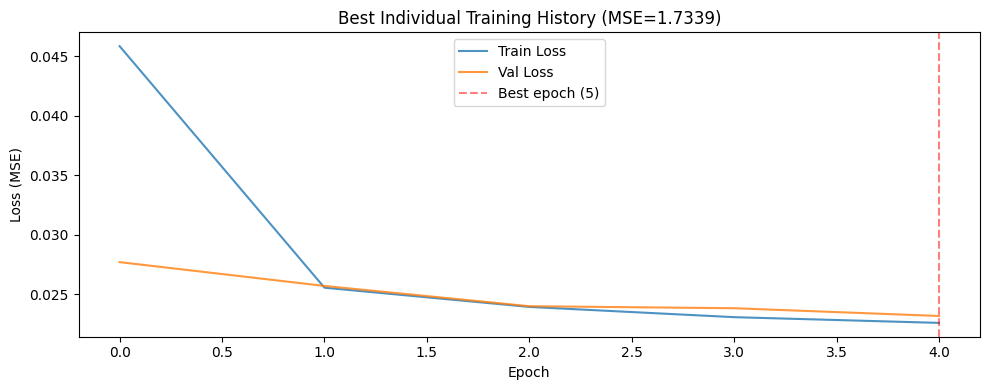

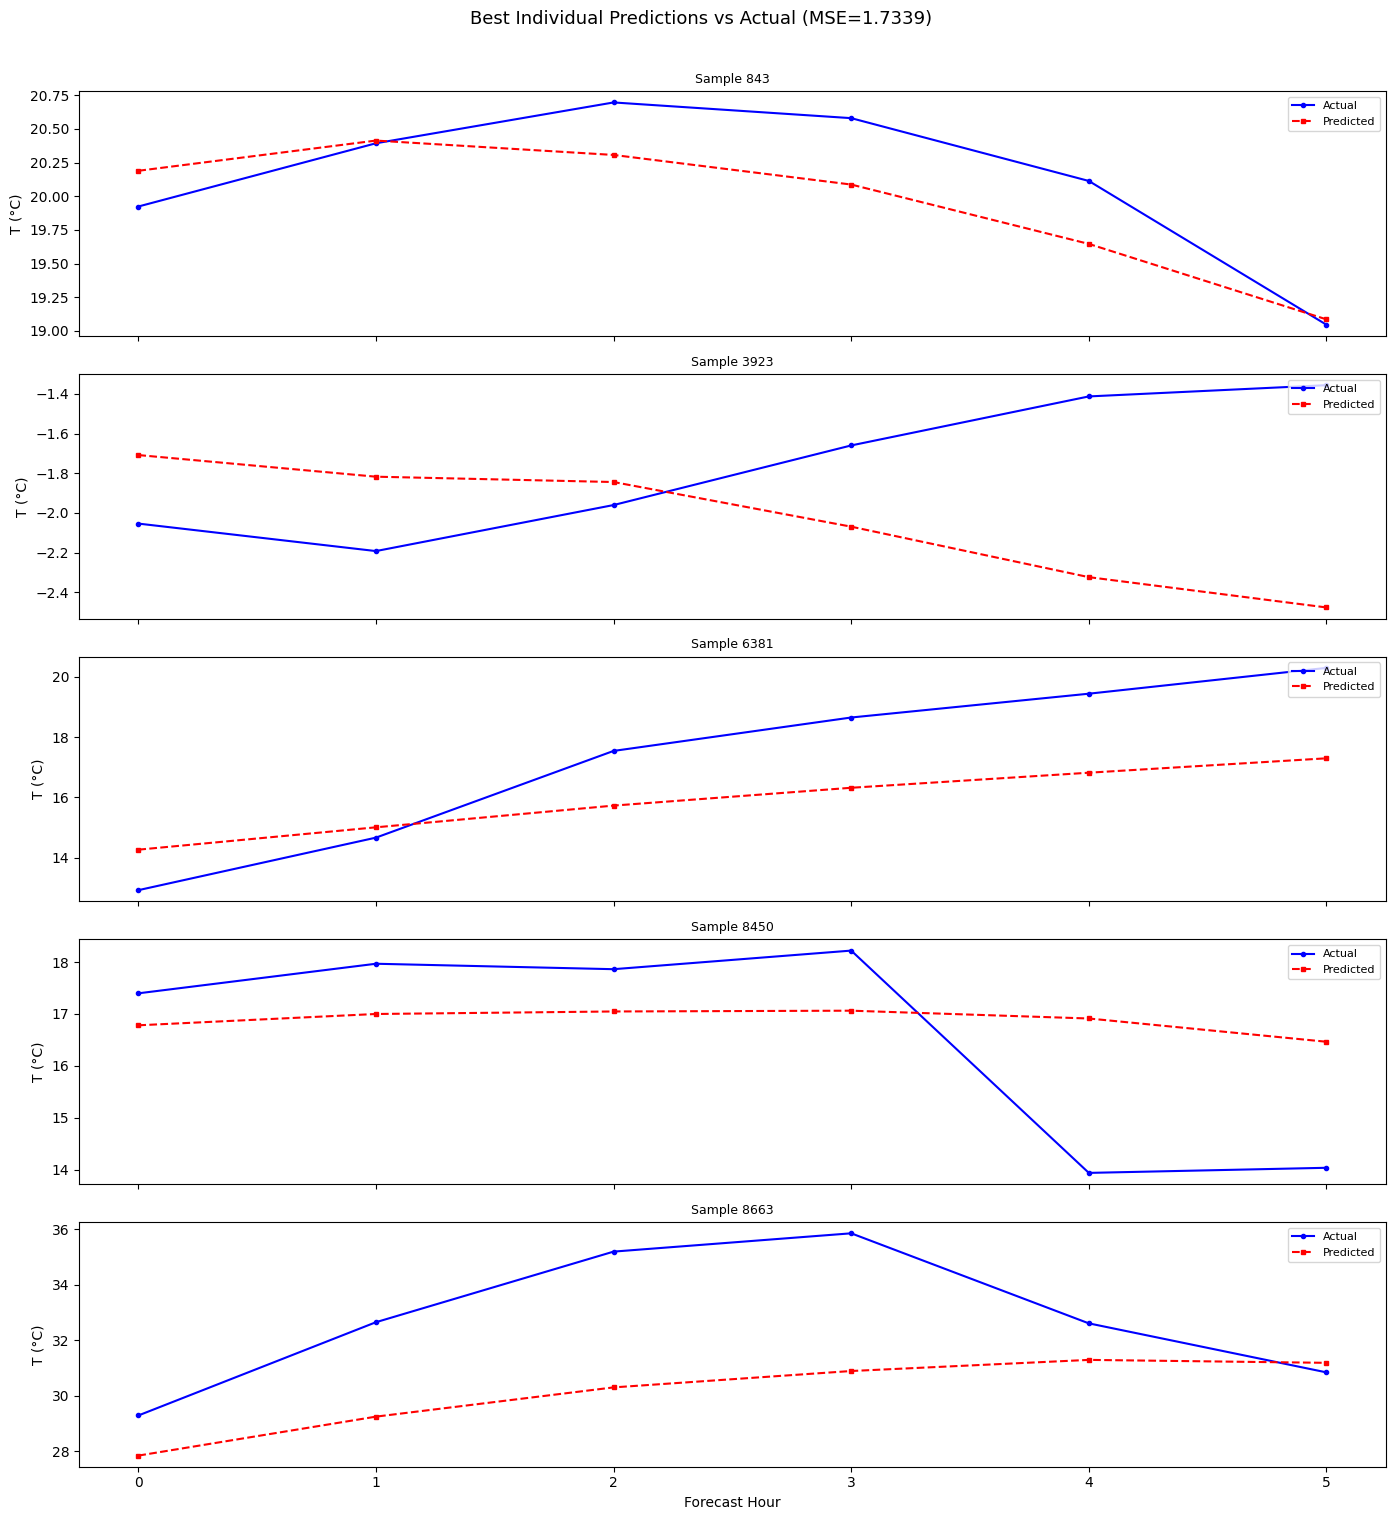

In [41]:
# plots for the best individual
best_individual, best_fitness_tuple = best_overall_tuple
best_fitness = best_fitness_tuple[0]
best_history = best_fitness_tuple[3]
best_model_state = best_fitness_tuple[4]
best_y_true = best_fitness_tuple[5]
best_y_pred = best_fitness_tuple[6]
plot_training_history((best_history, best_model_state), title=f"Best Individual Training History (MSE={best_fitness:.4f})")
plot_predictions(best_y_true, best_y_pred, title=f"Best Individual Predictions vs Actual (MSE={best_fitness:.4f})", n_samples=5)


Test Results (original scale): MSE=1.5294 | RMSE=1.2367 | MAE=0.8830 | R²=0.9748
Test Results (scaled space):   MSE=0.02046 | MAE=0.10213
Inference time: 0.39s | Parameters: 55,302


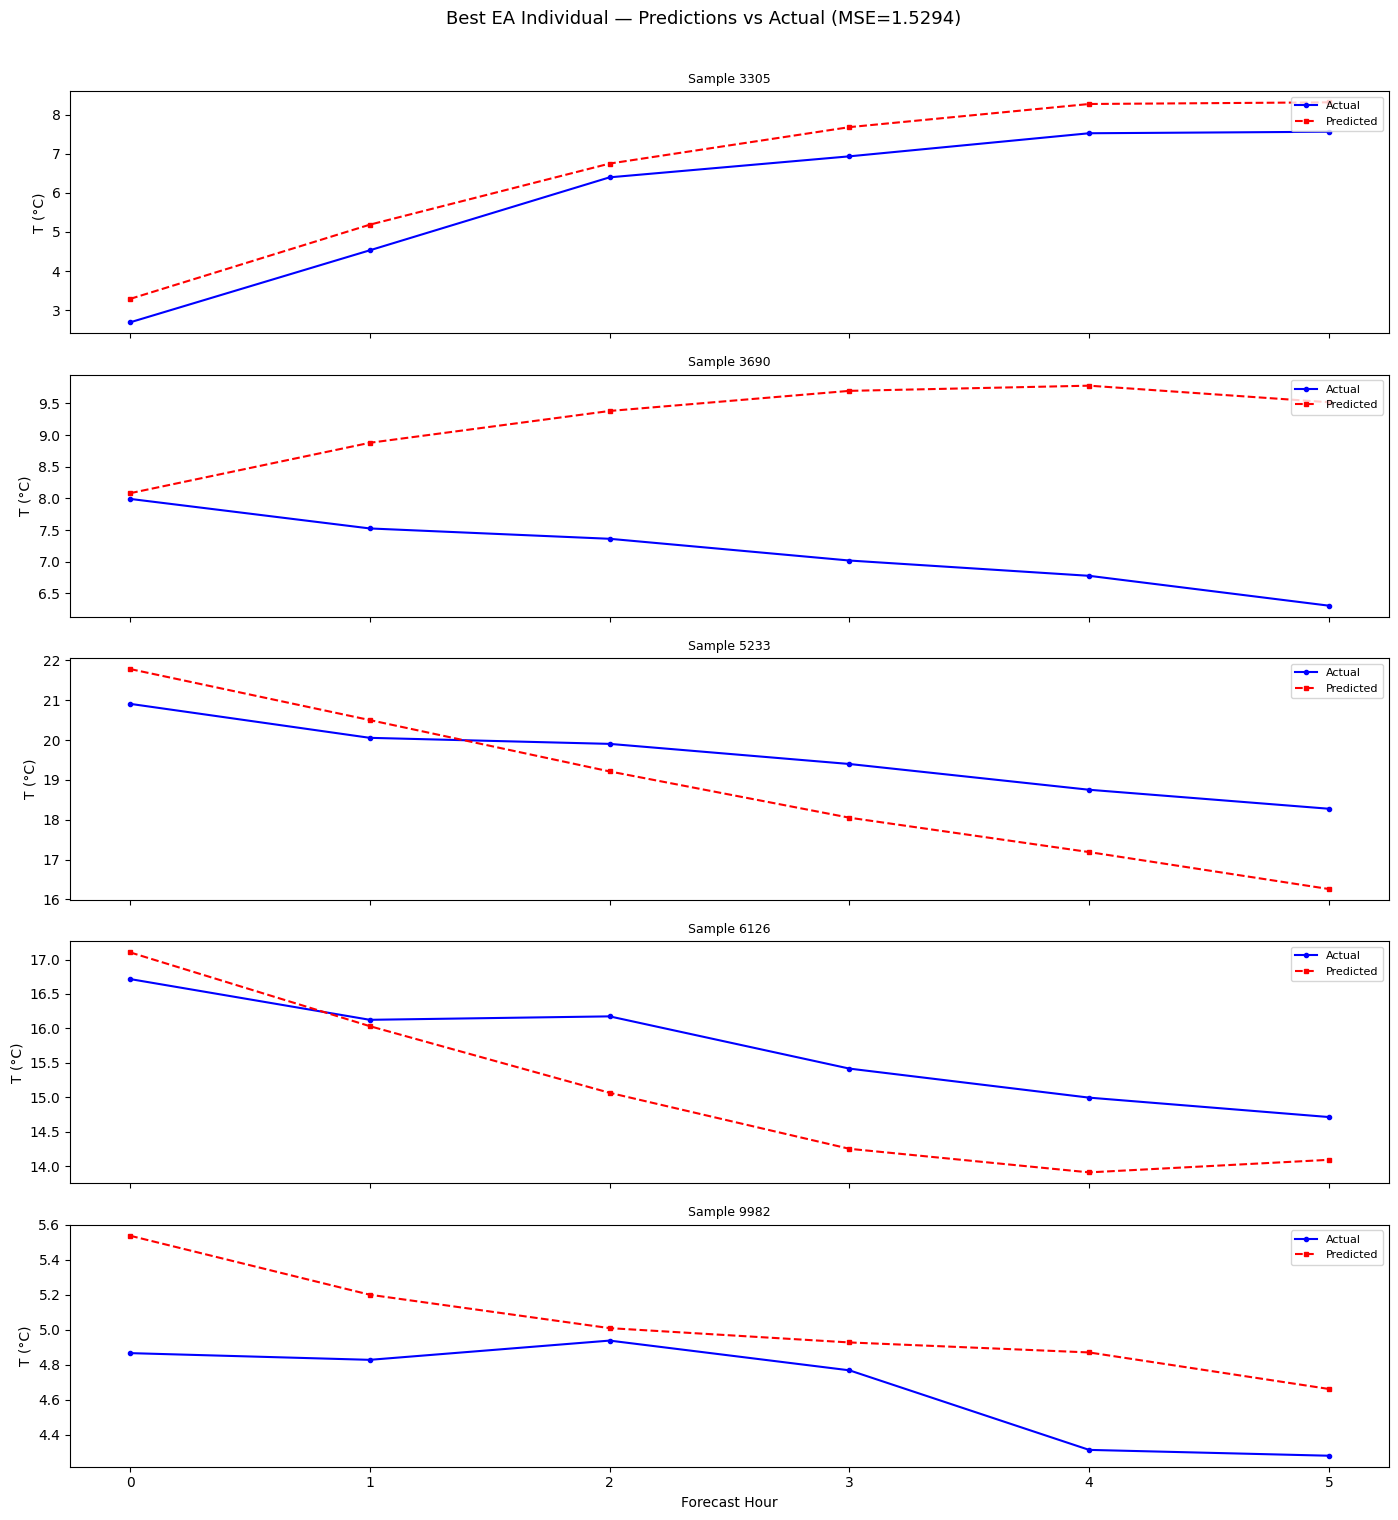

In [42]:
# Evaluate the loaded best EA model and plot
criterion = nn.MSELoss()
ea_results = evaluate_model(best_ea_model, ea_test_loader, criterion, scaler, TARGET_IDX)

plot_predictions(ea_results['y_true'], ea_results['y_pred'], 
                 title=f"Best EA Individual — Predictions vs Actual (MSE={ea_results['mse']:.4f})", 
                 n_samples=5)


### 7.6.1 Run the best model for X epochs

Epoch   1/50 | Train: 0.022315 | Val: 0.023885 | Time: 3.3s ★
Epoch   2/50 | Train: 0.022030 | Val: 0.023144 | Time: 3.1s ★
Epoch   7/50 | Train: 0.021230 | Val: 0.022602 | Time: 3.2s ★
Epoch   9/50 | Train: 0.021036 | Val: 0.022389 | Time: 3.6s ★
Epoch  10/50 | Train: 0.020812 | Val: 0.022276 | Time: 5.6s ★
Epoch  20/50 | Train: 0.020399 | Val: 0.022141 | Time: 4.9s ★
Epoch  23/50 | Train: 0.020306 | Val: 0.021998 | Time: 2.7s ★
Epoch  30/50 | Train: 0.020056 | Val: 0.022833 | Time: 4.9s

Early stopping at epoch 33 (best: 23)

Training complete in 112.6s | Best epoch: 23 | Best val loss: 0.021998
Test Results (original scale): MSE=1.4889 | RMSE=1.2202 | MAE=0.8707 | R²=0.9755
Test Results (scaled space):   MSE=0.01992 | MAE=0.10071
Inference time: 0.27s | Parameters: 55,302


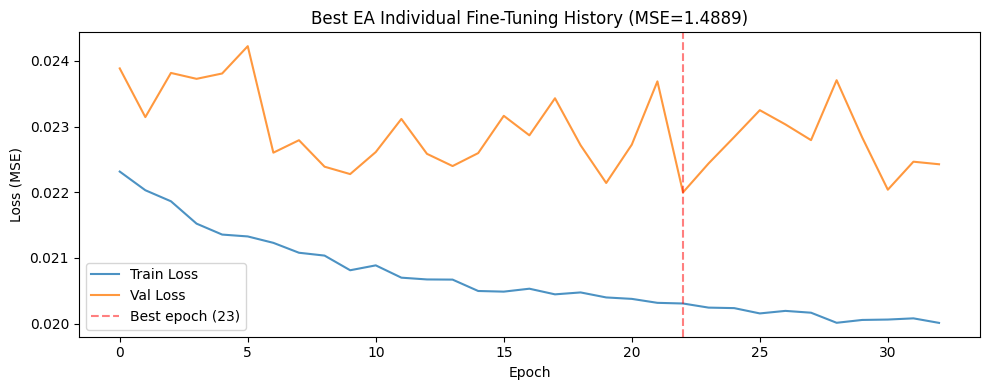

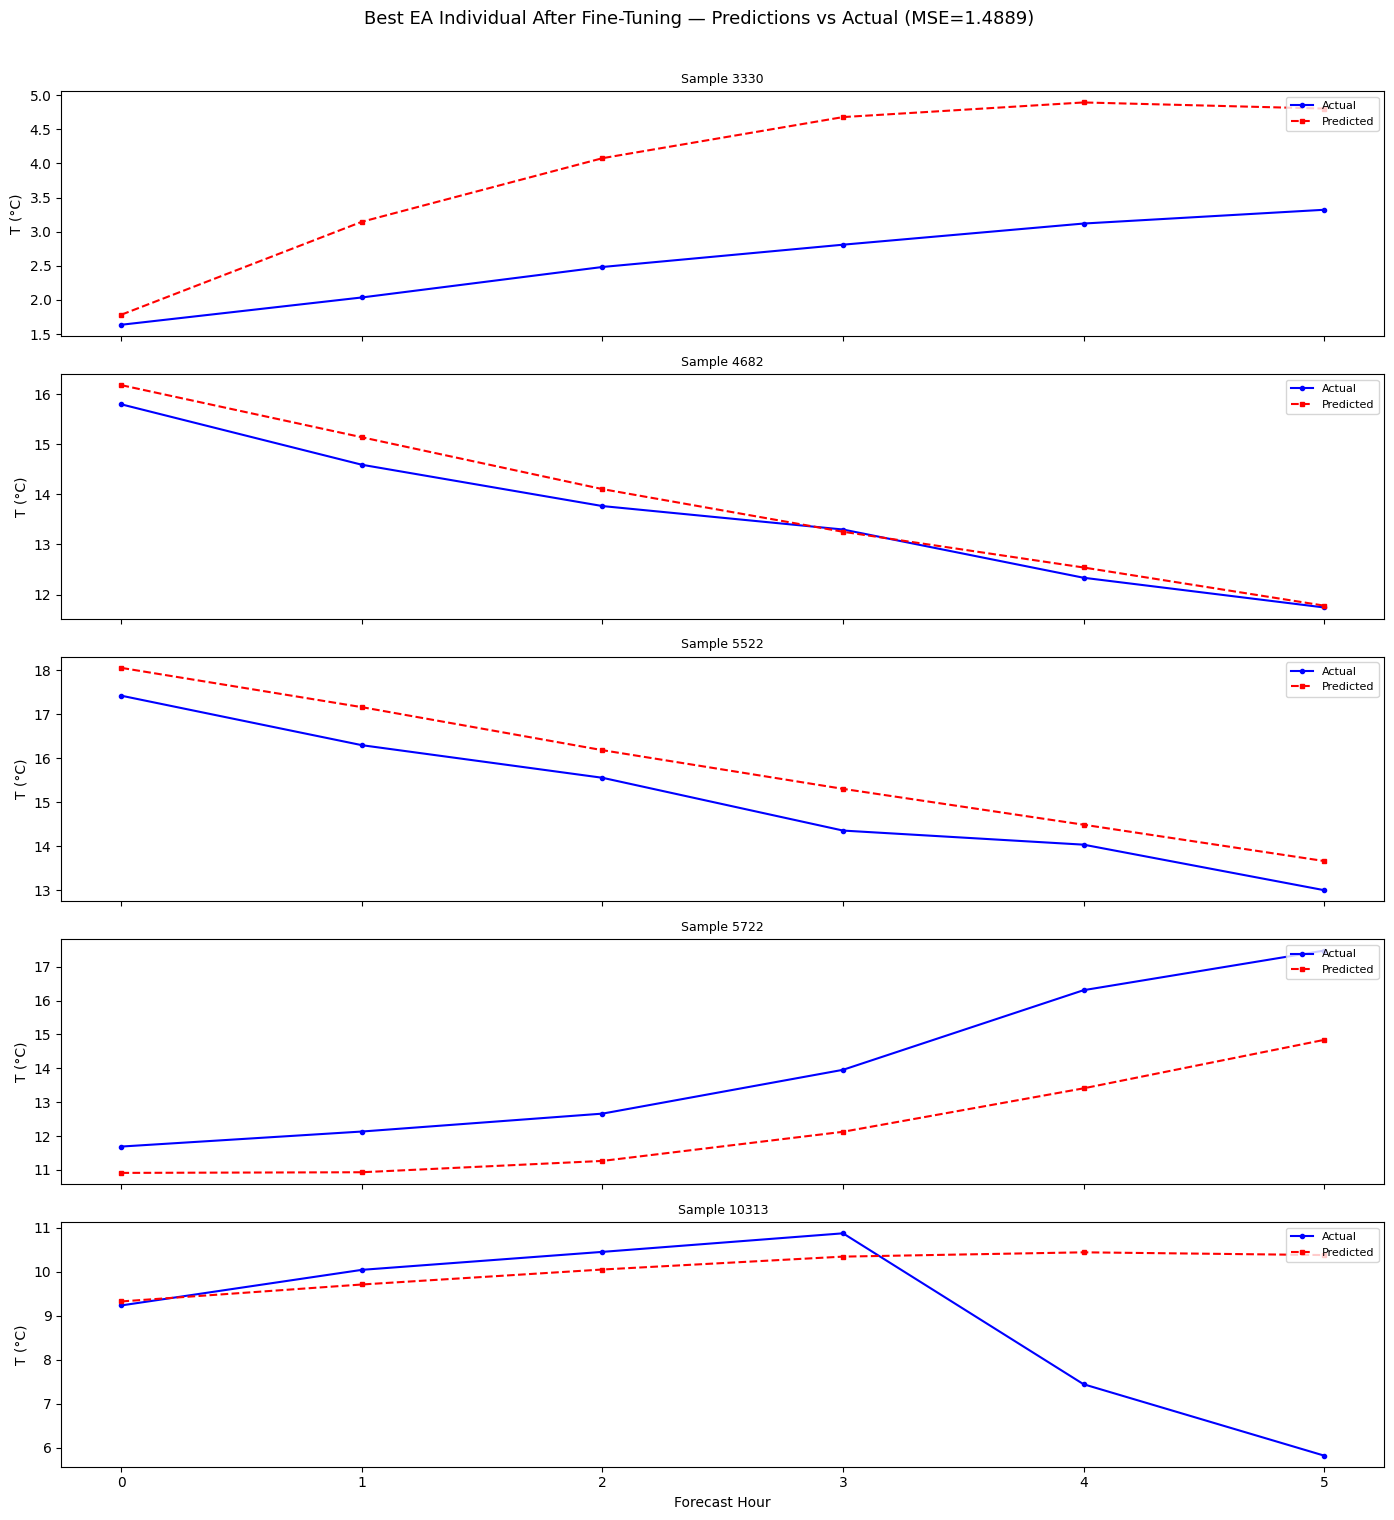

In [43]:
# run model for 50 epochs to see if it can improve with more training
optimizer = torch.optim.Adam(best_ea_model.parameters(), lr=float(best_config['learning_rate']), weight_decay=1e-4)
history_fine_tune = train_model(best_ea_model, 
                               DataLoader(TimeSeriesDataset(X_train_ea, y_train_ea), batch_size=ea_batch_size, shuffle=True), 
                               DataLoader(TimeSeriesDataset(X_val_ea, y_val_ea), batch_size=ea_batch_size, shuffle=False), 
                               optimizer, criterion, num_epochs=50, patience=10)

# Evaluate after fine-tuning
ea_results_fine_tune = evaluate_model(best_ea_model, ea_test_loader, criterion, scaler, TARGET_IDX)
plot_training_history(history_fine_tune, title=f"Best EA Individual Fine-Tuning History (MSE={ea_results_fine_tune['mse']:.4f})")
plot_predictions(ea_results_fine_tune['y_true'], ea_results_fine_tune['y_pred'], 
                 title=f"Best EA Individual After Fine-Tuning — Predictions vs Actual (MSE={ea_results_fine_tune['mse']:.4f})")


In [44]:
# Compare optimized model vs baseline (quantitatively)
print("\n" + "="*60)
print("FINAL COMPARISON: BEST EA MODEL VS BASELINE")
print("="*60)
print(f"{'Metric':<20} {'Best EA':>12} {'Baseline':>12}")
print("-"*44)
for m in ['mse', 'rmse', 'mae', 'r2']:
    print(f"{m.upper():<20} {ea_results[m]:>12.4f} {gru_results[m]:>12.4f}")
print(f"{'MSE (scaled)':<20} {ea_results['mse_scaled']:>12.5f} {gru_results['mse_scaled']:>12.5f}")
print(f"{'MAE (scaled)':<20} {ea_results['mae_scaled']:>12.5f} {gru_results['mae_scaled']:>12.5f}")
print(f"{'Parameters':<20} {ea_results['num_params']:>12,} {gru_results['num_params']:>12,}")
print(f"{'Inference (s)':<20} {ea_results['inference_time']:>12.2f} {gru_results['inference_time']:>12.2f}")



FINAL COMPARISON: BEST EA MODEL VS BASELINE
Metric                    Best EA     Baseline
--------------------------------------------
MSE                        1.5294       5.2339
RMSE                       1.2367       2.2878
MAE                        0.8830       1.7285
R2                         0.9748       0.9137
MSE (scaled)              0.02046      0.07003
MAE (scaled)              0.10213      0.19994
Parameters                 55,302      156,696
Inference (s)                0.39         0.24


---
## 8. Synthetic Data Generation (Optional/Bonus)

Explore generative approaches (e.g., GAN-based) for data augmentation.

**⚠️ Data Leakage Warning:** Synthetic data must be generated using the **training set only**.

Generating augmented training data...
  jitter: generated 49090 synthetic samples
  scaling: generated 49090 synthetic samples
  time_warp: generated 49090 synthetic samples

Original training size: 49,090
Augmented training size: 196,360 (4x)


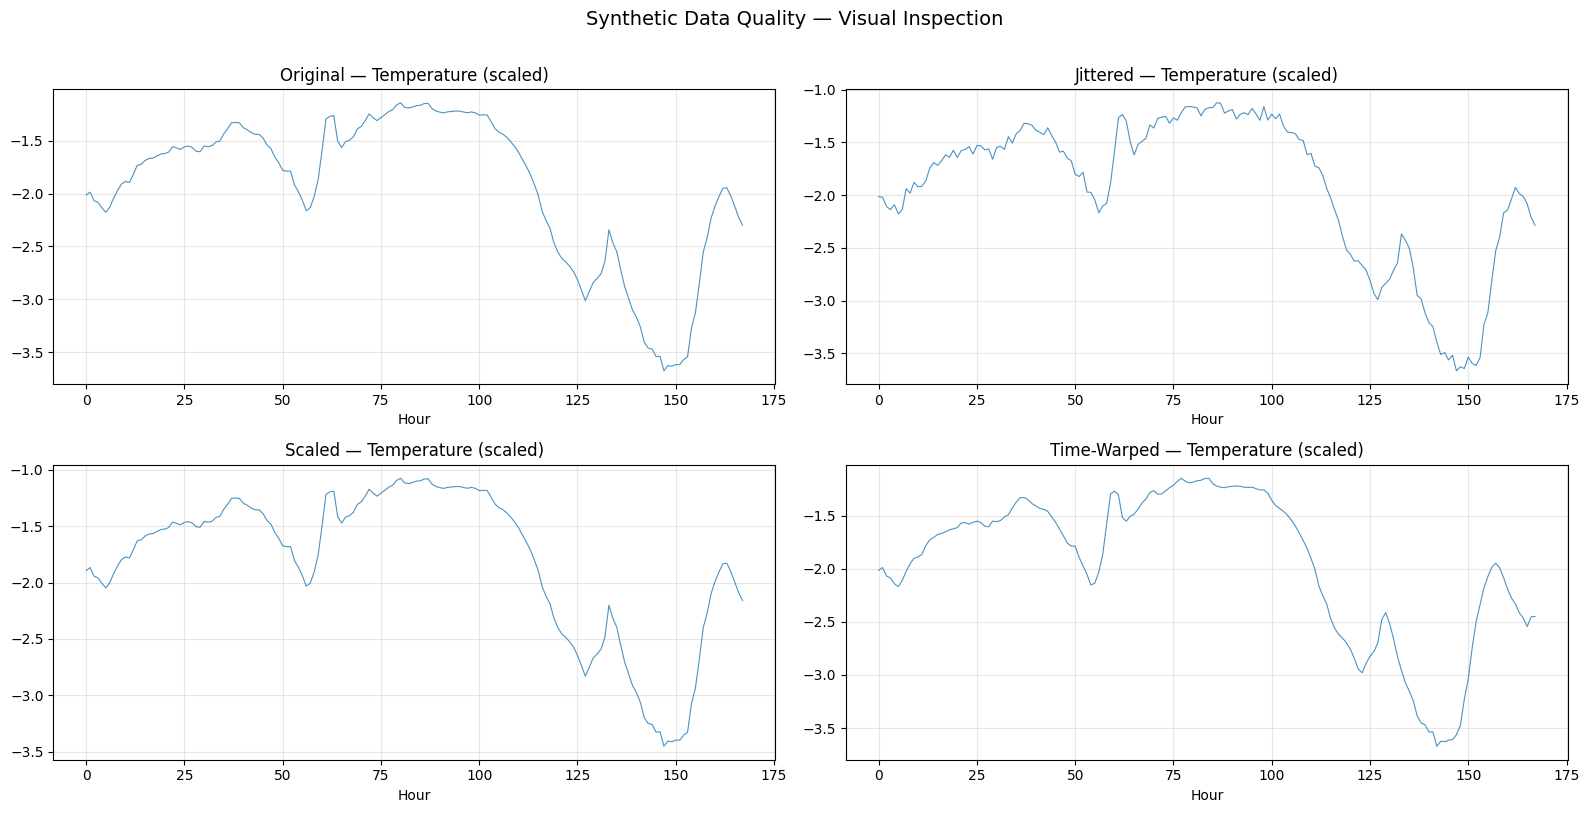

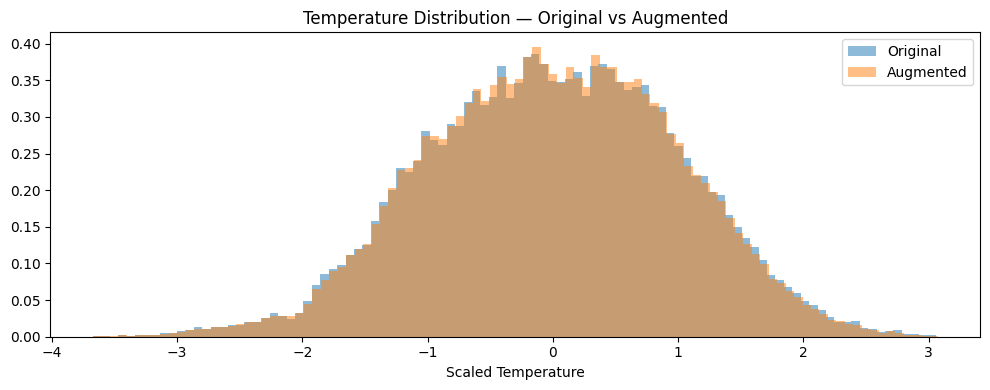


Augmented windows: 196,265 (vs original 48,995)

--- Training GRU on AUGMENTED data ---
Epoch   1/100 | Train: 0.125687 | Val: 0.084815 | Time: 9.6s ★
Epoch   2/100 | Train: 0.088294 | Val: 0.079423 | Time: 10.5s ★
Epoch   3/100 | Train: 0.083588 | Val: 0.078178 | Time: 8.5s ★
Epoch   4/100 | Train: 0.079451 | Val: 0.077249 | Time: 8.3s ★
Epoch   5/100 | Train: 0.075569 | Val: 0.074277 | Time: 8.2s ★
Epoch  10/100 | Train: 0.064702 | Val: 0.075616 | Time: 9.9s

Early stopping at epoch 15 (best: 5)

Training complete in 138.3s | Best epoch: 5 | Best val loss: 0.074277

=== COMPARISON: Original vs Augmented Training ===

--- GRU Baseline (original data) ---
Test Results (original scale): MSE=5.2339 | RMSE=2.2878 | MAE=1.7285 | R²=0.9137
Test Results (scaled space):   MSE=0.07003 | MAE=0.19994
Inference time: 0.32s | Parameters: 156,696

--- GRU (augmented data) ---
Test Results (original scale): MSE=5.4721 | RMSE=2.3392 | MAE=1.7476 | R²=0.9098
Test Results (scaled space):   MSE=0.07322

In [45]:
# --- 8. Synthetic Data Augmentation (Bonus) ---
# Three lightweight augmentation techniques applied to TRAINING data ONLY.
# This avoids data leakage while increasing training diversity.

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 8.1 Augmentation Functions
# ============================================================

def jitter(data, sigma=0.03):
    """Add small Gaussian noise to simulate sensor uncertainty."""
    noise = np.random.normal(0, sigma, data.shape)
    return data + noise

def scaling(data, sigma=0.1):
    """Multiply each feature by a random factor close to 1.0 to simulate amplitude variation."""
    factor = np.random.normal(1.0, sigma, size=(1, data.shape[1]))
    return data * factor

def time_warp(data, sigma=0.2):
    """Slightly stretch/compress random segments of the time series."""
    result = data.copy()
    n_steps = data.shape[0]
    
    # Create a smooth warping path
    warp_steps = np.linspace(0, n_steps - 1, num=4)
    warp_values = warp_steps + np.random.normal(0, sigma * n_steps / 4, size=4)
    warp_values = np.clip(warp_values, 0, n_steps - 1)
    warp_values[0], warp_values[-1] = 0, n_steps - 1  # Fix endpoints
    
    # Interpolate to get new time indices
    new_indices = np.interp(np.arange(n_steps), warp_steps, warp_values)
    new_indices = np.clip(new_indices, 0, n_steps - 1)
    
    for col in range(data.shape[1]):
        result[:, col] = np.interp(np.arange(n_steps), new_indices, data[:, col])
    
    return result

# ============================================================
# 8.2 Generate Synthetic Training Data (from train_scaled ONLY)
# ============================================================
print("Generating augmented training data...")

augmented_sets = []

# Apply each technique independently — this triples the training data
for i, aug_fn in enumerate([jitter, scaling, time_warp]):
    aug_data = aug_fn(train_scaled.copy())
    augmented_sets.append(aug_data)
    print(f"  {aug_fn.__name__}: generated {len(aug_data)} synthetic samples")

# Combine: original + 3 augmented copies
train_augmented = np.concatenate([train_scaled] + augmented_sets, axis=0)
print(f"\nOriginal training size: {len(train_scaled):,}")
print(f"Augmented training size: {len(train_augmented):,} (4x)")

# ============================================================
# 8.3 Visual Quality Check
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
sample_range = slice(0, 168)  # 1 week of data
titles = ['Original', 'Jittered', 'Scaled', 'Time-Warped']
datasets = [train_scaled, augmented_sets[0], augmented_sets[1], augmented_sets[2]]

for ax, title, data in zip(axes.flatten(), titles, datasets):
    ax.plot(data[sample_range, TARGET_IDX], alpha=0.8, linewidth=0.8)
    ax.set_title(f'{title} — Temperature (scaled)')
    ax.set_xlabel('Hour')
    ax.grid(True, alpha=0.3)

plt.suptitle('Synthetic Data Quality — Visual Inspection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Distribution comparison
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_scaled[:, TARGET_IDX], bins=100, alpha=0.5, label='Original', density=True)
ax.hist(train_augmented[:, TARGET_IDX], bins=100, alpha=0.5, label='Augmented', density=True)
ax.set_title('Temperature Distribution — Original vs Augmented')
ax.set_xlabel('Scaled Temperature')
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 8.4 Train Model WITH Augmented Data & Compare
# ============================================================
# Create augmented DataLoaders
X_train_aug, y_train_aug = create_windows(train_augmented, TARGET_IDX, LOOKBACK, HORIZON)
train_aug_loader = DataLoader(TimeSeriesDataset(X_train_aug, y_train_aug), 
                              batch_size=BATCH_SIZE, shuffle=True)

print(f"\nAugmented windows: {X_train_aug.shape[0]:,} (vs original {X_train.shape[0]:,})")

# Train a GRU with the SAME architecture as baseline but on augmented data
gru_augmented = TimeSeriesGRU(
    input_dim=len(ALL_COLS), hidden_dim=128, num_layers=2,
    output_dim=HORIZON, dropout=0.5
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_augmented.parameters(), lr=1e-4, weight_decay=1e-4)

print("\n--- Training GRU on AUGMENTED data ---")
aug_history = train_model(gru_augmented, train_aug_loader, val_loader, optimizer, criterion,
                          num_epochs=100, patience=10)

# Evaluate both on the SAME test set
print("\n=== COMPARISON: Original vs Augmented Training ===")
print("\n--- GRU Baseline (original data) ---")
gru_orig_results = evaluate_model(gru_model, test_loader, criterion, scaler, TARGET_IDX)

print("\n--- GRU (augmented data) ---")
gru_aug_results = evaluate_model(gru_augmented, test_loader, criterion, scaler, TARGET_IDX)

# Summary table
print("\n" + "=" * 55)
print(f"{'Metric':<20} {'Original':<15} {'Augmented':<15}")
print("-" * 55)
for m in ['mse', 'rmse', 'mae', 'r2']:
    print(f"{m.upper():<20} {gru_orig_results[m]:<15.4f} {gru_aug_results[m]:<15.4f}")
print("=" * 55)


---
## 9. Explainable AI (XAI)

Apply XAI techniques to analyse and interpret the forecasting models.

**Required:**
- At least **one global** explanation method
- At least **one local** explanation method

### 9.1 Global Explainability

Understand the model's overall behaviour and feature importance.

### Permutation Feature Importance

For the global explainability analysis, the Permutation Feature Importance seemed to be the more appropriate method, since it is highly effective for multivariate time series forecasting because it is model-agnostic and evaluates feature importance by directly measuring the drop in predictive performance when a specific feature's information is destroyed (or, more precisely, shuffled). Unlike methods that require flattening the 3D temporal tensors (which destroys the sequential context), permutation allows us to maintain the (samples, lookback, features) structure while neutralizing exactly one meteorological variable at a time.
  

Running Permutation Feature Importance for GRU Baseline...
Test Results (original scale): MSE=88.2873 | RMSE=9.3961 | MAE=7.5343 | R²=-0.4549
Test Results (scaled space):   MSE=1.18133 | MAE=0.87152
Inference time: 0.24s | Parameters: 156,696
Test Results (original scale): MSE=6.8860 | RMSE=2.6241 | MAE=1.9588 | R²=0.8865
Test Results (scaled space):   MSE=0.09214 | MAE=0.22658
Inference time: 0.23s | Parameters: 156,696
Test Results (original scale): MSE=7.3196 | RMSE=2.7055 | MAE=2.0729 | R²=0.8794
Test Results (scaled space):   MSE=0.09794 | MAE=0.23978
Inference time: 0.21s | Parameters: 156,696
Test Results (original scale): MSE=7.3956 | RMSE=2.7195 | MAE=2.0681 | R²=0.8781
Test Results (scaled space):   MSE=0.09896 | MAE=0.23923
Inference time: 0.22s | Parameters: 156,696
Test Results (original scale): MSE=8.6009 | RMSE=2.9327 | MAE=2.2074 | R²=0.8583
Test Results (scaled space):   MSE=0.11508 | MAE=0.25534
Inference time: 0.22s | Parameters: 156,696
Test Results (original scale)

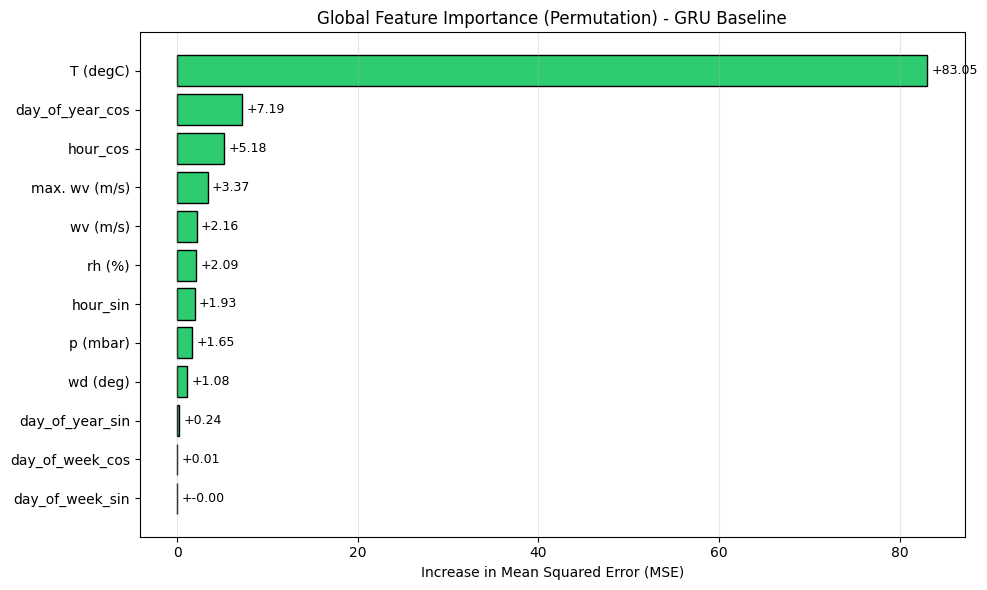

Running Permutation Feature Importance for Transformer Baseline...
Test Results (original scale): MSE=76.6047 | RMSE=8.7524 | MAE=7.0094 | R²=-0.2624
Test Results (scaled space):   MSE=1.02501 | MAE=0.81081
Inference time: 0.28s | Parameters: 115,160
Test Results (original scale): MSE=6.2731 | RMSE=2.5046 | MAE=1.8634 | R²=0.8966
Test Results (scaled space):   MSE=0.08394 | MAE=0.21555
Inference time: 0.27s | Parameters: 115,160
Test Results (original scale): MSE=6.6629 | RMSE=2.5813 | MAE=1.9628 | R²=0.8902
Test Results (scaled space):   MSE=0.08915 | MAE=0.22705
Inference time: 0.27s | Parameters: 115,160
Test Results (original scale): MSE=7.0146 | RMSE=2.6485 | MAE=2.0048 | R²=0.8844
Test Results (scaled space):   MSE=0.09386 | MAE=0.23190
Inference time: 0.28s | Parameters: 115,160
Test Results (original scale): MSE=9.4174 | RMSE=3.0688 | MAE=2.2749 | R²=0.8448
Test Results (scaled space):   MSE=0.12601 | MAE=0.26315
Inference time: 0.28s | Parameters: 115,160
Test Results (origina

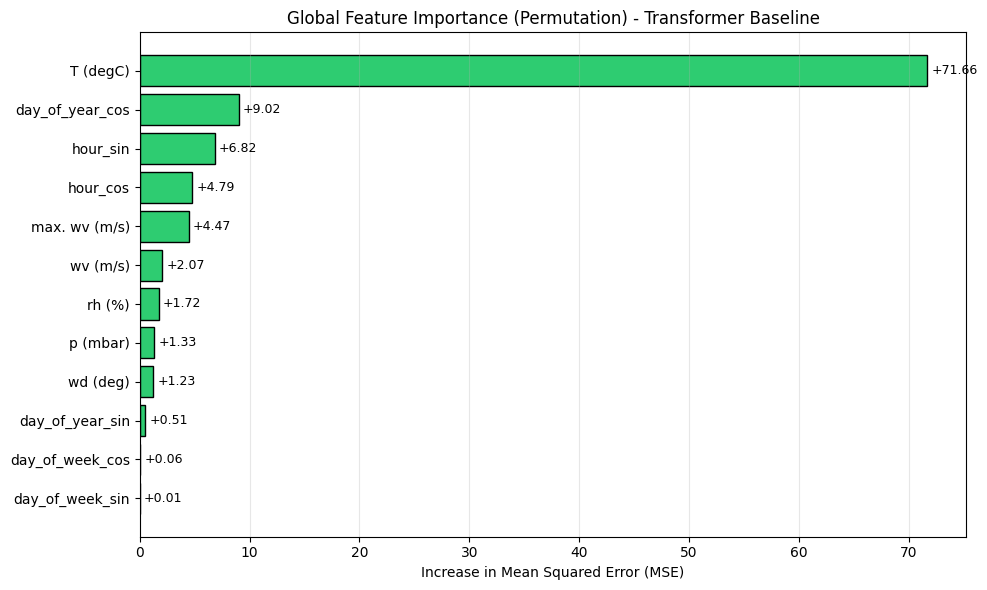

Running Permutation Feature Importance for EA-Optimized GRU...
Test Results (original scale): MSE=106.2648 | RMSE=10.3085 | MAE=8.2934 | R²=-0.7502
Test Results (scaled space):   MSE=1.42187 | MAE=0.95934
Inference time: 0.16s | Parameters: 55,302
Test Results (original scale): MSE=1.7481 | RMSE=1.3222 | MAE=0.9372 | R²=0.9712
Test Results (scaled space):   MSE=0.02339 | MAE=0.10841
Inference time: 0.15s | Parameters: 55,302
Test Results (original scale): MSE=2.3592 | RMSE=1.5360 | MAE=1.1025 | R²=0.9611
Test Results (scaled space):   MSE=0.03157 | MAE=0.12753
Inference time: 0.15s | Parameters: 55,302
Test Results (original scale): MSE=3.1368 | RMSE=1.7711 | MAE=1.1974 | R²=0.9483
Test Results (scaled space):   MSE=0.04197 | MAE=0.13851
Inference time: 0.16s | Parameters: 55,302
Test Results (original scale): MSE=3.6551 | RMSE=1.9118 | MAE=1.2797 | R²=0.9398
Test Results (scaled space):   MSE=0.04891 | MAE=0.14803
Inference time: 0.17s | Parameters: 55,302
Test Results (original scale

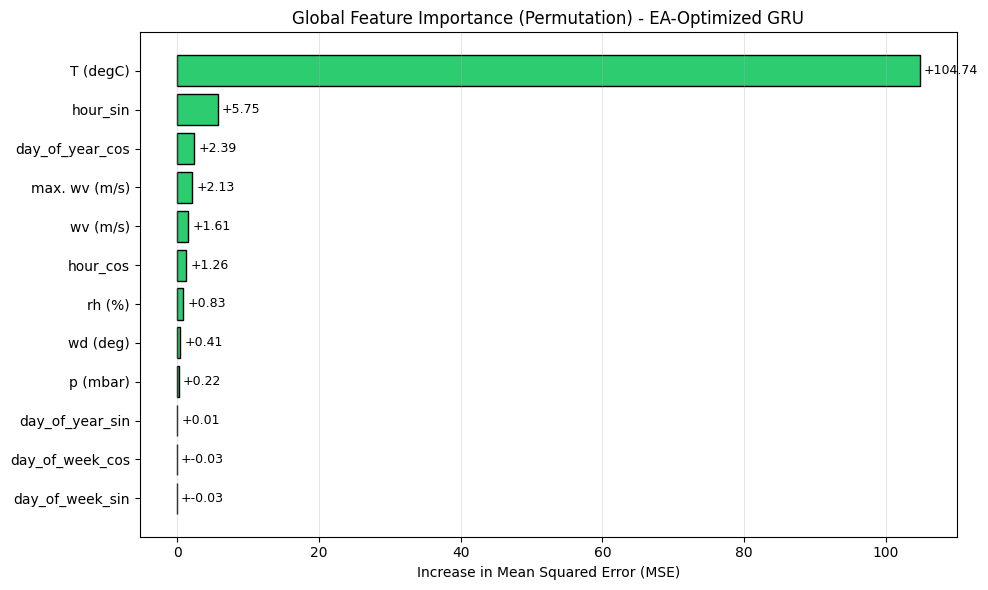

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def plot_permutation_importance(model, model_name, baseline_mse, X_test, y_test, criterion, scaler, target_idx, device):
    feature_names = [
        'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 
        'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 
        'day_of_week_sin', 'day_of_week_cos'
    ]
    
    importance_scores = {}
    print(f"Running Permutation Feature Importance for {model_name}...")

    for i, feat_name in enumerate(feature_names):
        X_test_shuffled = X_test.copy()
        np.random.shuffle(X_test_shuffled[:, :, i])
        
        shuffled_dataset = TimeSeriesDataset(X_test_shuffled, y_test)
        shuffled_loader = DataLoader(shuffled_dataset, batch_size=64, shuffle=False)
        
        shuffled_results = evaluate_model(model, shuffled_loader, criterion, scaler, target_idx, device=device)
        
        error_increase = shuffled_results['mse'] - baseline_mse
        importance_scores[feat_name] = error_increase
        
    sorted_importance = dict(sorted(importance_scores.items(), key=lambda item: item[1]))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(list(sorted_importance.keys()), list(sorted_importance.values()), color='#2ecc71', edgecolor='black')

    for bar in bars:
        width = bar.get_width()
        ax.annotate(f'+{width:.2f}', xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=9)

    ax.set_xlabel('Increase in Mean Squared Error (MSE)')
    ax.set_title(f'Global Feature Importance (Permutation) - {model_name}')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

# Run for GRU
plot_permutation_importance(gru_model, "GRU Baseline", gru_results['mse'], X_test, y_test, criterion, scaler, TARGET_IDX, DEVICE)

# Run for Transformer
plot_permutation_importance(transformer_model, "Transformer Baseline", transformer_results['mse'], X_test, y_test, criterion, scaler, TARGET_IDX, DEVICE)

# Run for EA-optimized model
plot_permutation_importance(best_ea_model, "EA-Optimized GRU", ea_results['mse'], 
                            X_test_ea, y_test_ea, criterion, scaler, TARGET_IDX, DEVICE)


### 9.2 Local Explainability

Explain individual predictions — why did the model predict this specific value?

In [48]:
# --- 9.2 Local Explainability: Integrated Gradients ---
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients

# 1. Select interesting samples from the test sets
sample_idx = 5025

# Baseline inputs (Lookback = 72)
input_baseline = torch.tensor(X_test[sample_idx:sample_idx+1], dtype=torch.float32).to(DEVICE)
blank_baseline = torch.zeros_like(input_baseline).to(DEVICE)

# EA Model inputs (Lookback = EA Lookback, e.g., 48)
input_ea = torch.tensor(X_test_ea[sample_idx:sample_idx+1], dtype=torch.float32).to(DEVICE)
blank_ea = torch.zeros_like(input_ea).to(DEVICE)

# 2. Initialize the Integrated Gradients explainers
ig_gru = IntegratedGradients(gru_model)
ig_transformer = IntegratedGradients(transformer_model)
ig_ea = IntegratedGradients(best_ea_model)

# 3. Set the target forecast steps
# Let's explain the LAST hour for each model (Hour 24 for baselines, Hour 6 for EA)
target_baseline_step = 23 
target_ea_step = ea_horizon - 1 

print(f"Calculating gradients for Sample {sample_idx}...")

# 4. Calculate the attributions
with torch.backends.cudnn.flags(enabled=False):
    gru_attributions, _ = ig_gru.attribute(input_baseline, blank_baseline, target=target_baseline_step, return_convergence_delta=True)
    trans_attributions, _ = ig_transformer.attribute(input_baseline, blank_baseline, target=target_baseline_step, return_convergence_delta=True)
    ea_attributions, _ = ig_ea.attribute(input_ea, blank_ea, target=target_ea_step, return_convergence_delta=True)

# Convert to numpy arrays and drop the batch dimension for plotting
gru_attr_np = gru_attributions.squeeze().cpu().detach().numpy()
trans_attr_np = trans_attributions.squeeze().cpu().detach().numpy()
ea_attr_np = ea_attributions.squeeze().cpu().detach().numpy()

# 5. Plotting the Heatmaps
feature_names = [
    'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 
    'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 
    'day_of_week_sin', 'day_of_week_cos'
]

def plot_ig_heatmap(attributions, model_name, target_step, lookback_len):
    fig, ax = plt.subplots(figsize=(16, 6))
    
    sns.heatmap(attributions.T, cmap="RdBu_r", center=0, robust=True,
                yticklabels=feature_names, 
                xticklabels=False,
                cbar_kws={'label': 'Attribution Score'},
                ax=ax)
    
    tick_positions = np.arange(0, lookback_len, 6)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels(tick_positions + 1, rotation=0, fontsize=9)
    
    ax.set_title(f'Integrated Gradients — {model_name} (Predicting +{target_step+1}h)', fontsize=13)
    ax.set_xlabel(f'Lookback Hour (1 = Oldest, {lookback_len} = Most Recent)')
    ax.set_ylabel('Features')
    plt.tight_layout()
    plt.show()


# Generate the plots, passing the correct lookback length for the X-axis mapping
plot_ig_heatmap(gru_attr_np, "GRU Baseline", target_baseline_step, 72)
plot_ig_heatmap(trans_attr_np, "Transformer Baseline", target_baseline_step, 72)
plot_ig_heatmap(ea_attr_np, "EA-Optimized GRU", target_ea_step, ea_lookback)


Calculating gradients for Sample 5025...


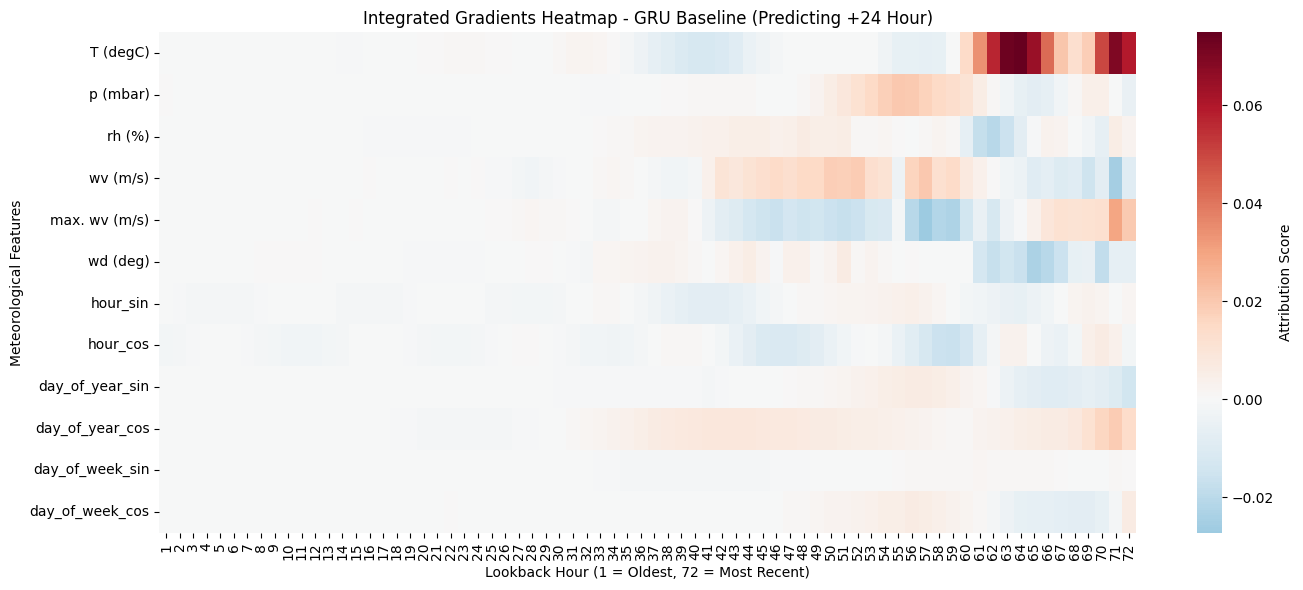

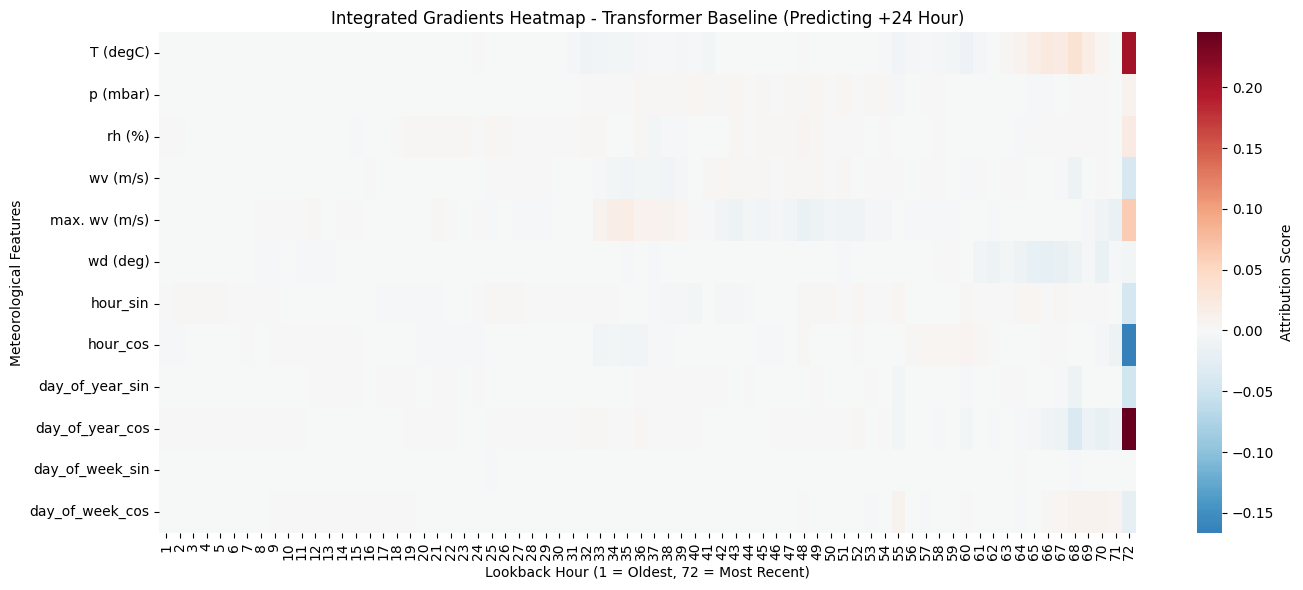

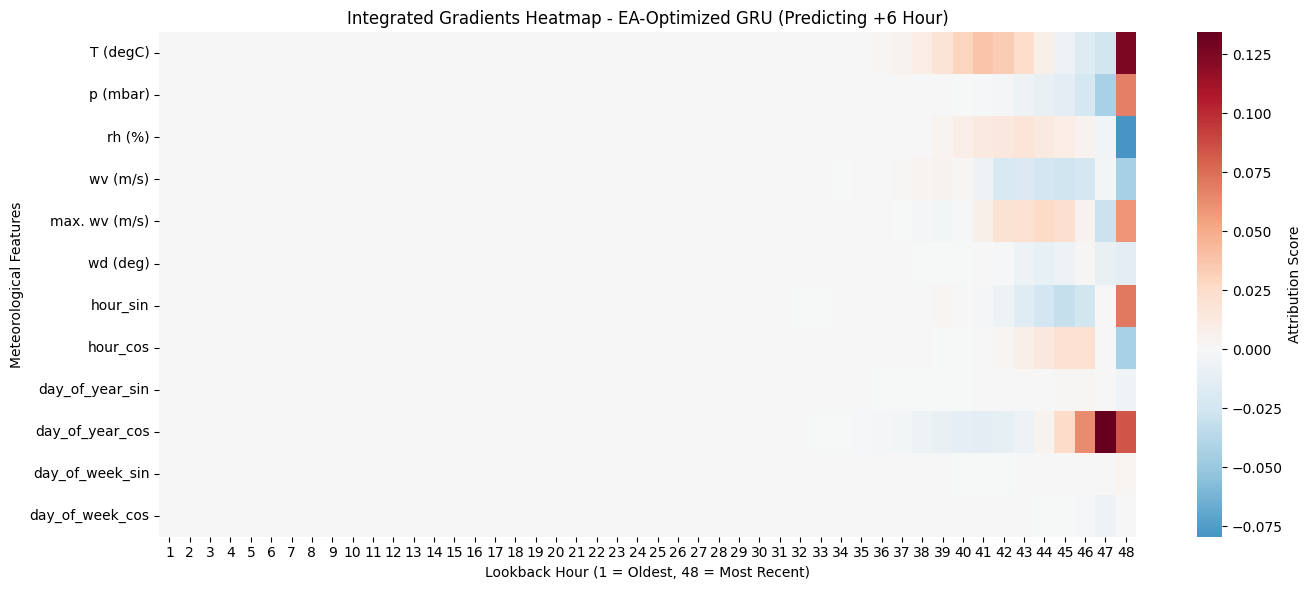

In [ ]:
# --- 9.3 Local Explainability: Deep SHAP (GradientExplainer) ---
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# 1. Define the target forecasting step (predicting the 24th hour)
target_forecast_step = 23

# 2. Create a Model Wrapper
# SHAP gets confused by multi-step outputs (predicting 24 hours at once).
# This wrapper hides the other 23 hours so SHAP only focuses on the exact hour we want.
class SingleStepWrapper(torch.nn.Module):
    def __init__(self, base_model, target_step):
        super().__init__()
        self.base_model = base_model
        self.target_step = target_step

    def forward(self, x):
        # Only return the prediction for the target hour
        predictions = self.base_model(x)
        return predictions[:, self.target_step].unsqueeze(1)

wrapped_gru = SingleStepWrapper(gru_model, target_forecast_step).to(DEVICE)
wrapped_transformer = SingleStepWrapper(transformer_model, target_forecast_step).to(DEVICE)

# 3. Create a "Background Dataset"
# SHAP needs a realistic frame of reference to compare against.
# We will grab 100 random samples from the test set to act as our baseline average.
background_tensor = torch.tensor(X_test[:100], dtype=torch.float32).to(DEVICE)

# 4. Initialize the SHAP Explainers
print("Initializing SHAP Explainers (this takes a few seconds)...")
explainer_gru = shap.GradientExplainer(wrapped_gru, background_tensor)
explainer_transformer = shap.GradientExplainer(wrapped_transformer, background_tensor)

# 5. Select our specific test sample (Sample 5025)
sample_idx = 5025
test_tensor = torch.tensor(X_test[sample_idx:sample_idx+1], dtype=torch.float32).to(DEVICE)

# 6. Calculate SHAP Values
with torch.backends.cudnn.flags(enabled=False):
    shap_values_gru = explainer_gru.shap_values(test_tensor)
    shap_values_trans = explainer_transformer.shap_values(test_tensor)


# Extract SHAP grids — squeeze out all size-1 dimensions to get (72, 12)
shap_grid_gru = np.squeeze(np.array(shap_values_gru))
shap_grid_trans = np.squeeze(np.array(shap_values_trans))

print(f"SHAP grid shapes — GRU: {shap_grid_gru.shape}, Transformer: {shap_grid_trans.shape}")

# 7. Plotting the SHAP Heatmaps
feature_names = [
    'T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 
    'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 
    'day_of_week_sin', 'day_of_week_cos'
]

def plot_shap_heatmap(shap_grid, model_name, target_step, lookback_len):
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Use robust=True to clip outliers and reveal the full pattern
    sns.heatmap(shap_grid.T, cmap="RdBu_r", center=0, robust=True,
                yticklabels=feature_names, 
                xticklabels=False,  # We'll set them manually
                cbar_kws={'label': 'SHAP Value'},
                ax=ax)
    
    # Clean X-axis: show every 6th hour
    tick_positions = np.arange(0, lookback_len, 6)
    ax.set_xticks(tick_positions + 0.5)
    ax.set_xticklabels(tick_positions + 1, rotation=0, fontsize=9)
    
    ax.set_title(f'Deep SHAP — {model_name} (Predicting +{target_step+1}h)', fontsize=13)
    ax.set_xlabel(f'Lookback Hour (1 = Oldest, {lookback_len} = Most Recent)')
    ax.set_ylabel('Features')
    plt.tight_layout()
    plt.show()

# --- Add EA-Optimized Model to SHAP comparison ---

# EA model predicts only 6 hours, so target the last hour (index 5)
ea_target_step = ea_horizon - 1

# Wrap the EA model the same way
wrapped_ea = SingleStepWrapper(best_ea_model, ea_target_step).to(DEVICE)

# Background from EA's test set (different lookback window)
background_ea = torch.tensor(X_test_ea[:100], dtype=torch.float32).to(DEVICE)

# Initialize explainer and select the same sample index
explainer_ea = shap.GradientExplainer(wrapped_ea, background_ea)
test_tensor_ea = torch.tensor(X_test_ea[sample_idx:sample_idx+1], dtype=torch.float32).to(DEVICE)

# Calculate SHAP values
print(f"\nCalculating SHAP values for EA-Optimized GRU (Sample {sample_idx})...")
with torch.backends.cudnn.flags(enabled=False):
    shap_values_ea = explainer_ea.shap_values(test_tensor_ea)

shap_grid_ea = np.squeeze(np.array(shap_values_ea))
print(f"SHAP grid shape — EA: {shap_grid_ea.shape}")

# Plot all three
plot_shap_heatmap(shap_grid_gru, "GRU Baseline", target_forecast_step, LOOKBACK)
plot_shap_heatmap(shap_grid_trans, "Transformer Baseline", target_forecast_step, LOOKBACK)
plot_shap_heatmap(shap_grid_ea, "EA-Optimized GRU", ea_target_step, ea_lookback)


---
## 10. Efficiency & Resource Analysis

Analyse computational costs and trade-offs between performance and efficiency.

**Required metrics:**
- Training time
- Inference time
- Number of model parameters
- Memory usage (RAM and/or GPU)

In [49]:
# --- 10. Efficiency & Resource Analysis ---
import time
import torch
import pandas as pd

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_time(model, test_loader, device, n_runs=3):
    model.eval()
    total_times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.time()
            for X_batch, _ in test_loader:
                _ = model(X_batch.to(device))
            total_times.append(time.time() - start)
    return sum(total_times) / len(total_times)

def measure_peak_memory(model, sample_input, device):
    if not torch.cuda.is_available():
        return "N/A (CPU)"
    model.eval()
    torch.cuda.reset_peak_memory_stats(device)
    with torch.no_grad():
        _ = model(sample_input.to(device))
    return round(torch.cuda.max_memory_allocated(device) / (1024 * 1024), 2)

# --- Build the full comparison table ---
criterion = nn.MSELoss()

# Evaluate all three models (accuracy metrics)
gru_results = evaluate_model(gru_model, test_loader, criterion, scaler, TARGET_IDX)
transformer_results = evaluate_model(transformer_model, test_loader, criterion, scaler, TARGET_IDX)
ea_results = evaluate_model(best_ea_model, ea_test_loader, criterion, scaler, TARGET_IDX)

# Measure efficiency metrics
models_info = [
    ("GRU Baseline",        gru_model,        test_loader,    LOOKBACK, HORIZON),
    ("Transformer Baseline", transformer_model, test_loader,    LOOKBACK, HORIZON),
    ("EA-Optimized GRU",    best_ea_model,    ea_test_loader, ea_lookback, ea_horizon),
]
results_list = [gru_results, transformer_results, ea_results]

rows = []
for (name, model, loader, lb, hz), res in zip(models_info, results_list):
    sample_batch, _ = next(iter(loader))
    rows.append({
        'Model':               name,
        'Lookback (h)':        lb,
        'Horizon (h)':         hz,
        'Parameters':          count_parameters(model),
        'MSE (°C²)':           round(res['mse'], 4),
        'RMSE (°C)':           round(res['rmse'], 4),
        'MAE (°C)':            round(res['mae'], 4),
        'R²':                  round(res['r2'], 4),
        'Inference Time (s)':  round(measure_inference_time(model, loader, DEVICE), 4),
        'Peak GPU Memory (MB)': measure_peak_memory(model, sample_batch, DEVICE),
    })

df_comparison = pd.DataFrame(rows)
display(df_comparison)


Test Results (original scale): MSE=5.2339 | RMSE=2.2878 | MAE=1.7285 | R²=0.9137
Test Results (scaled space):   MSE=0.07003 | MAE=0.19994
Inference time: 0.33s | Parameters: 156,696
Test Results (original scale): MSE=4.9447 | RMSE=2.2237 | MAE=1.6716 | R²=0.9185
Test Results (scaled space):   MSE=0.06616 | MAE=0.19336
Inference time: 0.26s | Parameters: 115,160
Test Results (original scale): MSE=1.4889 | RMSE=1.2202 | MAE=0.8707 | R²=0.9755
Test Results (scaled space):   MSE=0.01992 | MAE=0.10071
Inference time: 0.21s | Parameters: 55,302


,Model,Lookback (h),Horizon (h),Parameters,MSE (°C²),RMSE (°C),MAE (°C),R²,Inference Time (s),Peak GPU Memory (MB)
0,GRU Baseline,72,24,156696,5.2339,2.2878,1.7285,0.9137,0.1519,77.59
1,Transformer Baseline,72,24,115160,4.9447,2.2237,1.6716,0.9185,0.2208,46.96
2,EA-Optimized GRU,72,6,55302,1.4889,1.2202,0.8707,0.9755,0.1660,65.49


---
## 11. Comparative Analysis & Discussion

**This is one of the most important parts of the project.**

Provide a thorough analysis covering all aspects of the work.

### 11.1 Baseline vs Optimized Model Comparison

In [ ]:
# TODO: Compare baseline and optimized models
# - Side-by-side prediction plots
# - Metric comparison table (MSE, RMSE, MAE, MAPE, R²)
# - Statistical significance tests if applicable
# - How much did evolutionary optimization improve performance?

### 11.2 Discussion Points

Address each of these in written analysis (markdown cells):

**TODO: Write detailed discussion covering:**

1. **Impact of Evolutionary Optimization**
   - What improvements did the EA achieve over the baseline?
   - What pipeline components had the largest impact?
   - Did multi-objective optimization reveal interesting trade-offs?

2. **Insights from Explainability (XAI)**
   - What did the global explanations reveal about feature importance?
   - What did local explanations show about individual predictions?
   - Do the explanations align with meteorological domain knowledge?
   - How do explanations differ between baseline and optimized models?

3. **Accuracy vs Complexity vs Efficiency Trade-offs**
   - Is the optimized model significantly better than the baseline?
   - Is the improvement worth the additional complexity?
   - How do training/inference costs scale?

4. **Strengths and Limitations of the Final Solution**
   - What works well?
   - What are the failure modes?
   - What would you do differently with more time/resources?
   - Potential improvements and future work.

---
## 12. Conclusion

**TODO: Write a conclusion summarizing:**

- The problem addressed
- Key findings and results
- The most effective pipeline configuration found
- Main insights from explainability analysis
- Efficiency considerations
- Recommendations for future work